# Data Collection

## Install Packages and Load Data

In [ ]:
#!pip install beautifulsoup4 lxml

In [4]:
# Installs (run once) 
# !pip install nba_api scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import time
import os

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

from nba_api.stats.endpoints import (
    teamgamelog,
    leaguedashteamstats,
    leaguehustlestatsteam,
    commonteamroster,
    leaguestandings,
    playergamelog,
)
from nba_api.stats.static import teams as nba_teams_static

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})
LEAGUE_BLUE = "#1d428a"
LEAGUE_RED  = "#c8102e"
GRAY        = "#888888"

ALL_TEAMS    = nba_teams_static.get_teams()
TEAM_ID_MAP  = {t["id"]: t["full_name"]    for t in ALL_TEAMS}
TEAM_ABB_MAP = {t["id"]: t["abbreviation"] for t in ALL_TEAMS}
TEAM_NAME_TO_ID = {t["full_name"]: t["id"] for t in ALL_TEAMS}
TEAM_ABB_TO_ID  = {t["abbreviation"]: t["id"] for t in ALL_TEAMS}

SEASONS = [
    "2016-17", "2017-18", "2018-19", "2019-20",
    "2020-21", "2021-22", "2022-23", "2023-24",
    "2024-25", "2025-26"
]

ALLSTAR_DATES = {
    "2016-17": "2017-02-19",
    "2017-18": "2018-02-18",
    "2018-19": "2019-02-17",
    "2019-20": "2020-02-16",
    "2020-21": "2021-03-07",
    "2021-22": "2022-02-20",
    "2022-23": "2023-02-19",
    "2023-24": "2024-02-18",
    "2024-25": "2025-02-16",
    "2025-26": "2026-02-15",
}


## Ground Truth Labels

In [1]:
# Explicit public statements — front office, coaching staff, or star player publicly acknowledging tanking/rebuilding (Lillard quote, Hinkie documentation)
# Documented veteran teardown — team traded away its best players with no competitive replacement (Harden, CP3, Beal, Gobert + Mitchell, Zion + CJ)
# Media consensus — widespread narrative that the team was not competing, not just struggling
# Historic losing — outcomes so extreme they're hard to attribute to anything but intent (DET 2023-24 at 14 wins)

KNOWN_TANKERS = {
    # 2016-17
    ("PHI", "2016-17"),   # Hinkie Process — fully documented

    # 2017-2018
    ("DAL", "2017-18"),

    # 2020-21
    ("HOU", "2020-21"),   # Post-Harden trade, explicit rebuild
    ("OKC", "2020-21"),   # Post-CP3, all picks traded away

    # 2021-22
    ("HOU", "2021-22"),   # Year 2 rebuild
    ("OKC", "2021-22"),   # Year 2, explicit picks accumulation
    ("IND", "2021-22"),   # Traded veterans, explicit rebuild
    ("POR", "2021-22"),   # media consensus & quotes

    # 2022-23
    ("DET", "2022-23"),   # Historic lows, explicit youth movement
    ("HOU", "2022-23"),   # Year 3 rebuild
    ("SAS", "2022-23"),   # Post-Pop era, explicit rebuild
    ("POR", "2022-23"),   # media consensus

    # 2023-24
    ("DET", "2023-24"),   # 14 wins — worst in NBA
    ("SAS", "2023-24"),   # Wembanyama development year
    ("WAS", "2023-24"),   # Traded Beal, explicit teardown
    ("UTA", "2023-24"),   # Traded Gobert AND Mitchell
    ("CHA", "2023-24"),   # Explicit rebuild language
    ("POR", "2023-24"),   # Scoot Henderson rebuild

    # 2024-25
    ("WAS", "2024-25"),   # Year 2 teardown
    ("UTA", "2024-25"),   # Year 2 post-Gobert/Mitchell
    ("NOP", "2024-25"),   # Traded Zion, CJ, explicit teardown
    ("CHA", "2024-25"),   # Continued rebuild
    ("PHI", "2024-25"),   # Embiid injured, explicit rebuild pivot

    # 2025-26
    ("WAS", "2025-26"),   # Year 3 teardown
    ("BKN", "2025-26"),   # Full teardown after KD/Kyrie era
    ("UTA", "2025-26"),
    ("IND", "2025-26"),
    ("SAC", "2025-26"),
    ("MEM", "2025-26")
}

## Vegas Preseason Win Totals

In [5]:
VEGAS_WIN_TOTALS = {
    # 2016-17
    ("ATL", "2016-17"): 43.5, ("BOS", "2016-17"): 52.5,
    ("BKN", "2016-17"): 21.5, ("CHA", "2016-17"): 42.5,
    ("CHI", "2016-17"): 39.0, ("CLE", "2016-17"): 56.5,
    ("DAL", "2016-17"): 39.5, ("DEN", "2016-17"): 37.0,
    ("DET", "2016-17"): 44.5, ("GSW", "2016-17"): 66.5,
    ("HOU", "2016-17"): 44.0, ("IND", "2016-17"): 44.5,
    ("LAC", "2016-17"): 53.5, ("LAL", "2016-17"): 24.5,
    ("MEM", "2016-17"): 42.5, ("MIA", "2016-17"): 34.5,
    ("MIL", "2016-17"): 34.5, ("MIN", "2016-17"): 41.5,
    ("NOP", "2016-17"): 36.5, ("NYK", "2016-17"): 38.5,
    ("OKC", "2016-17"): 45.0, ("ORL", "2016-17"): 37.5,
    ("PHI", "2016-17"): 23.5, ("PHX", "2016-17"): 29.5,
    ("POR", "2016-17"): 45.5, ("SAC", "2016-17"): 33.5,
    ("SAS", "2016-17"): 57.5, ("TOR", "2016-17"): 50.5,
    ("UTA", "2016-17"): 47.5, ("WAS", "2016-17"): 42.5,

    # 2017-18
    ("ATL", "2017-18"): 25.5, ("BOS", "2017-18"): 53.5,
    ("BKN", "2017-18"): 27.5, ("CHA", "2017-18"): 42.5,
    ("CHI", "2017-18"): 22.0, ("CLE", "2017-18"): 53.5,
    ("DAL", "2017-18"): 35.5, ("DEN", "2017-18"): 45.5,
    ("DET", "2017-18"): 38.5, ("GSW", "2017-18"): 67.5,
    ("HOU", "2017-18"): 55.5, ("IND", "2017-18"): 31.5,
    ("LAC", "2017-18"): 43.5, ("LAL", "2017-18"): 33.5,
    ("MEM", "2017-18"): 37.5, ("MIA", "2017-18"): 43.5,
    ("MIL", "2017-18"): 47.5, ("MIN", "2017-18"): 48.5,
    ("NOP", "2017-18"): 39.5, ("NYK", "2017-18"): 30.5,
    ("OKC", "2017-18"): 53.5, ("ORL", "2017-18"): 33.5,
    ("PHI", "2017-18"): 39.5, ("PHX", "2017-18"): 28.5,
    ("POR", "2017-18"): 42.5, ("SAC", "2017-18"): 27.5,
    ("SAS", "2017-18"): 55.0, ("TOR", "2017-18"): 48.5,
    ("UTA", "2017-18"): 40.5, ("WAS", "2017-18"): 48.5,

   # 2018-19
   ("ATL", "2018-19"): 23.5,  ("BOS", "2018-19"): 59,
   ("BKN", "2018-19"): 32,    ("CHA", "2018-19"): 35.5,
   ("CHI", "2018-19"): 30,    ("CLE", "2018-19"): 30.5,
   ("DAL", "2018-19"): 35.5,  ("DEN", "2018-19"): 47.5,
   ("DET", "2018-19"): 38.5,  ("GSW", "2018-19"): 62.5,
   ("HOU", "2018-19"): 56.5,  ("IND", "2018-19"): 47.5,
   ("LAC", "2018-19"): 37,    ("LAL", "2018-19"): 48.5,
   ("MEM", "2018-19"): 34.5,  ("MIA", "2018-19"): 43,
   ("MIL", "2018-19"): 48,    ("MIN", "2018-19"): 41.5,
   ("NOP", "2018-19"): 45.5,  ("NYK", "2018-19"): 28.5,
   ("OKC", "2018-19"): 48.5,  ("ORL", "2018-19"): 31,
   ("PHI", "2018-19"): 53.5,  ("PHX", "2018-19"): 29,
   ("POR", "2018-19"): 42,    ("SAC", "2018-19"): 26,
   ("SAS", "2018-19"): 43.5,  ("TOR", "2018-19"): 55.5,
   ("UTA", "2018-19"): 49.5,  ("WAS", "2018-19"): 45.5,


    # 2019-20, may exclude
    ("ATL", "2019-20"): 33.5, ("BOS", "2019-20"): 48.5,
    ("BKN", "2019-20"): 43.5, ("CHA", "2019-20"): 23.5,
    ("CHI", "2019-20"): 33.5, ("CLE", "2019-20"): 24.5,
    ("DAL", "2019-20"): 40.5, ("DEN", "2019-20"): 53.0,
    ("DET", "2019-20"): 37.5, ("GSW", "2019-20"): 47.5,
    ("HOU", "2019-20"): 54.0, ("IND", "2019-20"): 46.5,
    ("LAC", "2019-20"): 53.5, ("LAL", "2019-20"): 50.5,
    ("MEM", "2019-20"): 27.5, ("MIA", "2019-20"): 43.5,
    ("MIL", "2019-20"): 57.5, ("MIN", "2019-20"): 35.5,
    ("NOP", "2019-20"): 37.5, ("NYK", "2019-20"): 26.5,
    ("OKC", "2019-20"): 32.5, ("ORL", "2019-20"): 41.5,
    ("PHI", "2019-20"): 54.5, ("PHX", "2019-20"): 29.5,
    ("POR", "2019-20"): 46.5, ("SAC", "2019-20"): 37.5,
    ("SAS", "2019-20"): 46.5, ("TOR", "2019-20"): 46.5,
    ("UTA", "2019-20"): 53.5, ("WAS", "2019-20"): 27.0,

    # 2020-21 
    ("ATL", "2020-21"): 34.5, ("BOS", "2020-21"): 44.5,
    ("BKN", "2020-21"): 45.5, ("CHA", "2020-21"): 26.5,
    ("CHI", "2020-21"): 29.5, ("CLE", "2020-21"): 22.5,
    ("DAL", "2020-21"): 42.5, ("DEN", "2020-21"): 44.5,
    ("DET", "2020-21"): 23.5, ("GSW", "2020-21"): 37.5,
    ("HOU", "2020-21"): 34.5, ("IND", "2020-21"): 38.5,
    ("LAC", "2020-21"): 46.5, ("LAL", "2020-21"): 47.5,
    ("MEM", "2020-21"): 31.5, ("MIA", "2020-21"): 43.5,
    ("MIL", "2020-21"): 49.5, ("MIN", "2020-21"): 29.5,
    ("NOP", "2020-21"): 36.5, ("NYK", "2020-21"): 21.5,
    ("OKC", "2020-21"): 22.5, ("ORL", "2020-21"): 31.5,
    ("PHI", "2020-21"): 43.5, ("PHX", "2020-21"): 38.5,
    ("POR", "2020-21"): 40.5, ("SAC", "2020-21"): 28.5,
    ("SAS", "2020-21"): 28.5, ("TOR", "2020-21"): 42.5,
    ("UTA", "2020-21"): 41.5, ("WAS", "2020-21"): 32.5,

    # 2021-22 
    ("ATL", "2021-22"): 47.5, ("BOS", "2021-22"): 45.5,
    ("BKN", "2021-22"): 56.5, ("CHA", "2021-22"): 38.5,
    ("CHI", "2021-22"): 42.5, ("CLE", "2021-22"): 26.5,
    ("DAL", "2021-22"): 48.5, ("DEN", "2021-22"): 47.5,
    ("DET", "2021-22"): 24.5, ("GSW", "2021-22"): 48.5,
    ("HOU", "2021-22"): 27.5, ("IND", "2021-22"): 42.5,
    ("LAC", "2021-22"): 45.5, ("LAL", "2021-22"): 52.5,
    ("MEM", "2021-22"): 41.5, ("MIA", "2021-22"): 48.5,
    ("MIL", "2021-22"): 54.5, ("MIN", "2021-22"): 35.5,
    ("NOP", "2021-22"): 39.5, ("NYK", "2021-22"): 41.5,
    ("OKC", "2021-22"): 23.5, ("ORL", "2021-22"): 22.5,
    ("PHI", "2021-22"): 50.5, ("PHX", "2021-22"): 51.5,
    ("POR", "2021-22"): 44.5, ("SAC", "2021-22"): 36.5,
    ("SAS", "2021-22"): 28.5, ("TOR", "2021-22"): 35.5,
    ("UTA", "2021-22"): 52.5, ("WAS", "2021-22"): 33.5,

    # 2022-23 
    ("ATL", "2022-23"): 46.5, ("BOS", "2022-23"): 54.5,
    ("BKN", "2022-23"): 50.5, ("CHA", "2022-23"): 34.5,
    ("CHI", "2022-23"): 41.5, ("CLE", "2022-23"): 46.5,
    ("DAL", "2022-23"): 48.5, ("DEN", "2022-23"): 51.5,
    ("DET", "2022-23"): 29.5, ("GSW", "2022-23"): 52.5,
    ("HOU", "2022-23"): 23.5, ("IND", "2022-23"): 24.5,
    ("LAC", "2022-23"): 52.5, ("LAL", "2022-23"): 44.5,
    ("MEM", "2022-23"): 49.5, ("MIA", "2022-23"): 49.5,
    ("MIL", "2022-23"): 53.5, ("MIN", "2022-23"): 49.5,
    ("NOP", "2022-23"): 45.5, ("NYK", "2022-23"): 38.5,
    ("OKC", "2022-23"): 23.5, ("ORL", "2022-23"): 26.5,
    ("PHI", "2022-23"): 50.5, ("PHX", "2022-23"): 52.5,
    ("POR", "2022-23"): 39.5, ("SAC", "2022-23"): 34.5,
    ("SAS", "2022-23"): 22.5, ("TOR", "2022-23"): 46.5,
    ("UTA", "2022-23"): 23.5, ("WAS", "2022-23"): 35.5,

    # 2023-24 
    ("ATL", "2023-24"): 42.5, ("BOS", "2023-24"): 54.5,
    ("BKN", "2023-24"): 37.5, ("CHA", "2023-24"): 31.5,
    ("CHI", "2023-24"): 37.5, ("CLE", "2023-24"): 50.5,
    ("DAL", "2023-24"): 45.5, ("DEN", "2023-24"): 52.5,
    ("DET", "2023-24"): 28.5, ("GSW", "2023-24"): 48.5,
    ("HOU", "2023-24"): 31.5, ("IND", "2023-24"): 38.5,
    ("LAC", "2023-24"): 46.5, ("LAL", "2023-24"): 47.5,
    ("MEM", "2023-24"): 45.5, ("MIA", "2023-24"): 45.5,
    ("MIL", "2023-24"): 54.5, ("MIN", "2023-24"): 44.5,
    ("NOP", "2023-24"): 44.5, ("NYK", "2023-24"): 45.5,
    ("OKC", "2023-24"): 44.5, ("ORL", "2023-24"): 37.5,
    ("PHI", "2023-24"): 48.5, ("PHX", "2023-24"): 51.5,
    ("POR", "2023-24"): 28.5, ("SAC", "2023-24"): 44.5,
    ("SAS", "2023-24"): 28.5, ("TOR", "2023-24"): 36.5,
    ("UTA", "2023-24"): 35.5, ("WAS", "2023-24"): 24.5,

    # 2024-25 (from Covers 2020s PDF)
    ("ATL", "2024-25"): 36.5, ("BOS", "2024-25"): 58.5,
    ("BKN", "2024-25"): 19.5, ("CHA", "2024-25"): 30.5,
    ("CHI", "2024-25"): 28.5, ("CLE", "2024-25"): 48.5,
    ("DAL", "2024-25"): 49.5, ("DEN", "2024-25"): 51.5,
    ("DET", "2024-25"): 25.5, ("GSW", "2024-25"): 43.5,
    ("HOU", "2024-25"): 43.5, ("IND", "2024-25"): 46.5,
    ("LAC", "2024-25"): 35.5, ("LAL", "2024-25"): 43.5,
    ("MEM", "2024-25"): 47.5, ("MIA", "2024-25"): 44.5,
    ("MIL", "2024-25"): 49.5, ("MIN", "2024-25"): 51.5,
    ("NOP", "2024-25"): 46.5, ("NYK", "2024-25"): 53.5,
    ("OKC", "2024-25"): 57.5, ("ORL", "2024-25"): 47.5,
    ("PHI", "2024-25"): 50.5, ("PHX", "2024-25"): 48.5,
    ("POR", "2024-25"): 21.5, ("SAC", "2024-25"): 46.5,
    ("SAS", "2024-25"): 35.5, ("TOR", "2024-25"): 29.5,
    ("UTA", "2024-25"): 28.5, ("WAS", "2024-25"): 20.5,

    # 2025-26 (from Covers 2020s PDF)
    ("ATL", "2025-26"): 46.5, ("BOS", "2025-26"): 41.5,
    ("BKN", "2025-26"): 19.5, ("CHA", "2025-26"): 27.5,
    ("CHI", "2025-26"): 33.5, ("CLE", "2025-26"): 56.5,
    ("DAL", "2025-26"): 41.5, ("DEN", "2025-26"): 53.5,
    ("DET", "2025-26"): 46.5, ("GSW", "2025-26"): 47.5,
    ("HOU", "2025-26"): 52.5, ("IND", "2025-26"): 37.5,
    ("LAC", "2025-26"): 49.5, ("LAL", "2025-26"): 46.5,
    ("MEM", "2025-26"): 39.5, ("MIA", "2025-26"): 37.5,
    ("MIL", "2025-26"): 43.5, ("MIN", "2025-26"): 49.5,
    ("NOP", "2025-26"): 30.5, ("NYK", "2025-26"): 53.5,
    ("OKC", "2025-26"): 62.5, ("ORL", "2025-26"): 51.5,
    ("PHI", "2025-26"): 43.5, ("PHX", "2025-26"): 30.5,
    ("POR", "2025-26"): 35.5, ("SAC", "2025-26"): 32.5,
    ("SAS", "2025-26"): 44.5, ("TOR", "2025-26"): 39.5,
    ("UTA", "2025-26"): 18.5, ("WAS", "2025-26"): 20.5,
}

## API Helper & Season Dates

In [8]:
import time

def safe_get(fn, retries=7, delay=5):
    for attempt in range(retries):
        try:
            time.sleep(delay)
            return fn()
        except Exception as e:
            if attempt < retries - 1:
                wait = delay * (2 ** attempt)
                print(f"  Retry {attempt+1}/{retries} in {wait}s — {e}")
                time.sleep(wait)
            else:
                print(f"  FAILED: {e}")
                return None

def season_start_end(season_str):
    year1, year2 = season_str.split("-")
    start    = f"{year1}-10-01"
    allstar  = ALLSTAR_DATES[season_str]
    full_yr2 = f"20{year2}" if len(year2) == 2 else year2
    end      = f"{full_yr2}-04-15"
    return start, allstar, end

## Pulling Team Game Logs

In [ ]:
from nba_api.stats.library import http as nba_http

nba_http.STATS_HEADERS = {
    "Host": "stats.nba.com",
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "x-nba-stats-origin": "stats",
    "x-nba-stats-token": "true",
    "Connection": "keep-alive",
    "Referer": "https://www.nba.com/",
    "Origin": "https://www.nba.com",
}
print("✓ Headers patched")

In [ ]:
def fetch_team_gamelogs(season):
    records  = []
    team_ids = [t["id"] for t in ALL_TEAMS]
    for i, tid in enumerate(team_ids):
        if i % 5 == 0:
            print(f"  {season}: team {i+1}/30", end="\r")
        result = safe_get(
            lambda tid=tid, season=season: teamgamelog.TeamGameLog(
                team_id=tid,
                season=season,
                season_type_all_star="Regular Season"
            ).get_data_frames()[0]
        )
        if result is not None:
            result["TEAM_ID"] = tid
            result["SEASON"]  = season
            records.append(result)
    print()
    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()

all_gamelogs = []
for season in SEASONS:
    print(f"Fetching: {season}")
    gl = fetch_team_gamelogs(season)
    if not gl.empty:
        all_gamelogs.append(gl)
        gl.to_csv(f"outputs/gamelogs_{season}.csv", index=False)

gamelogs_df = pd.concat(all_gamelogs, ignore_index=True)
gamelogs_df.to_csv("gamelogs/all_gamelogs.csv", index=False)
print(f"\n✓ Game logs: {len(gamelogs_df):,} rows")
gamelogs_df.head(3)

## Compute Plus/Minus and Win Rate 

In [ ]:
def compute_pm_delta(gamelogs_df, season, allstar_date):
    df = gamelogs_df[gamelogs_df["SEASON"] == season].copy()
    
    # Fix column name
    if "Team_ID" in df.columns and "TEAM_ID" not in df.columns:
        df = df.rename(columns={"Team_ID": "TEAM_ID"})
    
    df["GAME_DATE_DT"] = pd.to_datetime(df["GAME_DATE"])
    df["PTS"]          = pd.to_numeric(df["PTS"], errors="coerce")
    allstar_dt         = pd.to_datetime(allstar_date)
    
    # ── Compute true plus/minus via self-join on Game_ID ─────────────────────
    # Each game has two rows — merge team vs opponent by Game_ID
    merged = df.merge(
        df[["Game_ID", "TEAM_ID", "PTS"]].rename(columns={
            "TEAM_ID": "OPP_TEAM_ID",
            "PTS":     "OPP_PTS"
        }),
        on="Game_ID"
    )
    # Keep only rows where teams are different (drop self-match)
    merged = merged[merged["TEAM_ID"] != merged["OPP_TEAM_ID"]]
    merged["PLUS_MINUS"] = merged["PTS"] - merged["OPP_PTS"]

    results = []
    for tid, grp in merged.groupby("TEAM_ID"):
        pre  = grp[grp["GAME_DATE_DT"] <  allstar_dt]
        post = grp[grp["GAME_DATE_DT"] >= allstar_dt]

        def win_rate(sub):
            return (sub["WL"] == "W").mean() if len(sub) > 0 else np.nan

        results.append({
            "TEAM_ID":      tid,
            "SEASON":       season,
            "PM_PRE":       pre["PLUS_MINUS"].mean(),
            "PM_POST":      post["PLUS_MINUS"].mean(),
            "DELTA_PM":     post["PLUS_MINUS"].mean() - pre["PLUS_MINUS"].mean(),
            "WR_PRE":       win_rate(pre),
            "WR_POST":      win_rate(post),
            "DELTA_WR":     win_rate(post) - win_rate(pre),
            "N_GAMES_PRE":  len(pre),
            "N_GAMES_POST": len(post),
        })
    return pd.DataFrame(results)

all_pm = []
for season in SEASONS:
    pm = compute_pm_delta(gamelogs_df, season, ALLSTAR_DATES[season])
    all_pm.append(pm)

pm_df = pd.concat(all_pm, ignore_index=True)
pm_df.to_csv("outputs/pm_features.csv", index=False)
print(f"✓ PM/WR deltas: {pm_df.shape}")
pm_df.head(3)

## Download Hustle Stats

In [ ]:
from nba_api.stats.endpoints import leaguehustlestatsteam

# Explicit season date ranges for hustle API
SEASON_DATES = {
    "2016-17": ("10/25/2016", "02/18/2017", "02/20/2017", "04/12/2017"), # done
    "2017-18": ("10/17/2017", "02/17/2018", "02/19/2018", "04/11/2018"), # done
    "2018-19": ("10/16/2018", "02/16/2019", "02/18/2019", "04/10/2019"), # done
    "2019-20": ("10/22/2019", "02/15/2020", "02/17/2020", "08/14/2020"), # done
    "2020-21": ("12/22/2020", "03/06/2021", "03/08/2021", "05/16/2021"), #
    "2021-22": ("10/19/2021", "02/19/2022", "02/21/2022", "04/10/2022"), # done
    "2022-23": ("10/18/2022", "02/18/2023", "02/20/2023", "04/09/2023"), # done
    "2023-24": ("10/24/2023", "02/17/2024", "02/19/2024", "04/14/2024"), # done
    "2024-25": ("10/22/2024", "02/15/2025", "02/17/2025", "04/13/2025"), # done
    "2025-26": ("10/21/2025", "02/14/2026", "02/16/2026", "04/12/2026"), # done
}

def fetch_hustle_split(season, date_from, date_to):
    return safe_get(
        lambda: leaguehustlestatsteam.LeagueHustleStatsTeam(
            season=season,
            season_type_all_star="Regular Season",
            date_from_nullable=date_from,
            date_to_nullable=date_to,
            per_mode_time="PerGame",
        ).get_data_frames()[0]
    )

def compute_hustle_delta(season):
    pre_from, pre_to, post_from, post_to = SEASON_DATES[season]

    print(f"  PRE:  {pre_from} → {pre_to}")
    hustle_pre  = fetch_hustle_split(season, pre_from, pre_to)
    print(f"  POST: {post_from} → {post_to}")
    hustle_post = fetch_hustle_split(season, post_from, post_to)

    if hustle_pre is None or hustle_post is None:
        return None

    HUSTLE_COLS = [
        "TEAM_ID", "DEFLECTIONS", "CONTESTED_SHOTS",
        "LOOSE_BALLS_RECOVERED", "SCREEN_ASSISTS", "CHARGES_DRAWN",
    ]
    avail_pre  = [c for c in HUSTLE_COLS if c in hustle_pre.columns]
    avail_post = [c for c in HUSTLE_COLS if c in hustle_post.columns]

    merged = (hustle_pre[avail_pre]
              .merge(hustle_post[avail_post], on="TEAM_ID", suffixes=("_PRE","_POST")))

    for col in [c for c in avail_pre if c != "TEAM_ID"]:
        if f"{col}_PRE" in merged.columns and f"{col}_POST" in merged.columns:
            merged[f"DELTA_{col}"] = merged[f"{col}_POST"] - merged[f"{col}_PRE"]

    merged["SEASON"] = season
    return merged

all_hustle = []
for season in SEASONS:
    print(f"\nHustle: {season}")
    hd = compute_hustle_delta(season)
    if hd is not None:
        all_hustle.append(hd)

hustle_df = pd.concat(all_hustle, ignore_index=True)
hustle_df.to_csv("hustle_data/hustle_features.csv", index=False)
print(f"\n✓ Hustle features: {hustle_df.shape}")
hustle_df.head(3)

## Player Active/Inactive Rates 

In [49]:
import pandas as pd
import numpy as np
import os
import time

# Reload gamelogs from individual season CSVs
all_gamelogs = []
for season in SEASONS:
    path = f"outputs/gamelogs_{season}.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        all_gamelogs.append(df)
        print(f"✓ {season}: {len(df)} rows")
    else:
        print(f"⚠ Missing: {season}")

gamelogs_df = pd.concat(all_gamelogs, ignore_index=True)

# Fix column name
if "Team_ID" in gamelogs_df.columns and "TEAM_ID" not in gamelogs_df.columns:
    gamelogs_df = gamelogs_df.rename(columns={"Team_ID": "TEAM_ID"})

gamelogs_df.to_csv("outputs/all_gamelogs.csv", index=False)
print(f"\n✓ Gamelogs reloaded: {gamelogs_df.shape}")

✓ 2016-17: 2460 rows
✓ 2017-18: 2460 rows
✓ 2018-19: 2460 rows
✓ 2019-20: 2118 rows
✓ 2020-21: 2160 rows
✓ 2021-22: 2460 rows
✓ 2022-23: 2460 rows
✓ 2023-24: 2460 rows
✓ 2024-25: 2460 rows
✓ 2025-26: 2460 rows

✓ Gamelogs reloaded: (23958, 29)


In [50]:
def safe_get_fast(fn, retries=3, delay=1.5):
    """Faster version for player-level calls — fail quickly and move on."""
    for attempt in range(retries):
        try:
            time.sleep(delay)
            return fn()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(delay * 2)
            else:
                return None  # silently skip failed players

In [63]:
from nba_api.stats.endpoints import commonteamroster, playergamelog

def safe_get_fast(fn, retries=3, delay=1.5):
    for attempt in range(retries):
        try:
            time.sleep(delay)
            return fn()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(delay * 2)
            else:
                return None

def compute_availability_features(team_id, season, allstar_date):
    team_schedule = gamelogs_df[
        (gamelogs_df["TEAM_ID"] == team_id) &
        (gamelogs_df["SEASON"] == season)
    ][["Game_ID", "GAME_DATE"]].copy()
    team_schedule["GAME_DATE_DT"] = pd.to_datetime(team_schedule["GAME_DATE"], format='mixed')
    team_schedule = team_schedule.sort_values("GAME_DATE_DT").reset_index(drop=True)
    team_schedule["Game_ID_str"] = team_schedule["Game_ID"].astype(str).str.lstrip("0")

    base = {
        "TEAM_ID":               team_id,
        "SEASON":                season,
        "INACTIVE_RATE_PRE":     np.nan,
        "INACTIVE_RATE_POST":    np.nan,
        "DELTA_INACTIVE_RATE":   np.nan,
        "MIN_CONC_PRE":          np.nan,
        "MIN_CONC_POST":         np.nan,
        "DELTA_MIN_CONC":        np.nan,
        "TOP5_MIN_PRE":          np.nan,  # diagnostic only
        "TOP5_MIN_POST":         np.nan,  # diagnostic only
        "DELTA_TOP5_MIN_AVG":    np.nan,  # diagnostic only
        "ROOKIE_MIN_SHARE_PRE":  np.nan,
        "ROOKIE_MIN_SHARE_POST": np.nan,
        "DELTA_ROOKIE_MIN_SHARE":np.nan,
    }

    if team_schedule.empty:
        return base

    roster_result = safe_get_fast(
        lambda: commonteamroster.CommonTeamRoster(
            team_id=team_id, season=season
        ).get_data_frames()[0]
    )
    if roster_result is None or roster_result.empty:
        return base

    player_logs = []
    for _, player in roster_result.iterrows():
        time.sleep(0.6)
        log = safe_get_fast(
            lambda pid=player["PLAYER_ID"]: playergamelog.PlayerGameLog(
                player_id=pid,
                season=season,
                season_type_all_star="Regular Season"
            ).get_data_frames()[0]
        )
        if log is not None and not log.empty:
            log["PLAYER_ID"]   = player["PLAYER_ID"]
            log["PLAYER_NAME"] = player["PLAYER"]
            log["Game_ID_str"] = log["Game_ID"].astype(str).str.lstrip("0")
            player_logs.append(log)

    if not player_logs:
        return base

    all_logs = pd.concat(player_logs, ignore_index=True)
    all_logs["MIN_NUM"]      = pd.to_numeric(all_logs["MIN"], errors="coerce")
    all_logs["GAME_DATE_DT"] = pd.to_datetime(all_logs["GAME_DATE"], format='mixed')
    allstar_dt               = pd.to_datetime(allstar_date)

    pre_all  = all_logs[all_logs["GAME_DATE_DT"] <  allstar_dt]
    post_all = all_logs[all_logs["GAME_DATE_DT"] >= allstar_dt]

    # Top 5 players by avg mins per game min 20 games
    top_players = (all_logs.groupby("PLAYER_ID")["MIN_NUM"]
               .agg(["mean", "count"])
               .query("count >= 20")["mean"]
               .nlargest(5).index.tolist())
    top_logs = all_logs[all_logs["PLAYER_ID"].isin(top_players)].copy()

    # Diagnostic: raw top 5 minutes averages
    min_pre  = top_logs[top_logs["GAME_DATE_DT"] <  allstar_dt]["MIN_NUM"].mean()
    min_post = top_logs[top_logs["GAME_DATE_DT"] >= allstar_dt]["MIN_NUM"].mean()
    base["TOP5_MIN_PRE"]      = min_pre
    base["TOP5_MIN_POST"]     = min_post
    base["DELTA_TOP5_MIN_AVG"] = (min_post - min_pre) if not (pd.isna(min_pre) or pd.isna(min_post)) else np.nan

    # Minutes concentration: share of total team minutes going to top 5
    def concentration(df):
        total = df["MIN_NUM"].sum()
        top5  = df[df["PLAYER_ID"].isin(top_players)]["MIN_NUM"].sum()
        return top5 / total if total > 0 else np.nan

    conc_pre  = concentration(pre_all)
    conc_post = concentration(post_all)
    base["MIN_CONC_PRE"]   = conc_pre
    base["MIN_CONC_POST"]  = conc_post
    base["DELTA_MIN_CONC"] = (conc_post - conc_pre) if not (pd.isna(conc_pre) or pd.isna(conc_post)) else np.nan

    # Rookie/sophomore minute share
    rookie_ids = set(
    roster_result[pd.to_numeric(roster_result["EXP"], errors="coerce").isin([0, 1])]["PLAYER_ID"].tolist()
    )

    def rookie_min_share(df):
        total  = df["MIN_NUM"].sum()
        rookie = df[df["PLAYER_ID"].isin(rookie_ids)]["MIN_NUM"].sum()
        return rookie / total if total > 0 else np.nan

    rook_pre  = rookie_min_share(pre_all)
    rook_post = rookie_min_share(post_all)
    base["ROOKIE_MIN_SHARE_PRE"]    = rook_pre
    base["ROOKIE_MIN_SHARE_POST"]   = rook_post
    base["DELTA_ROOKIE_MIN_SHARE"]  = (rook_post - rook_pre) if not (pd.isna(rook_pre) or pd.isna(rook_post)) else np.nan

    # Inactive rate for top 5 players
    absence_records = []
    for pid, plogs in top_logs.groupby("PLAYER_ID"):
        played_games = set(plogs["Game_ID_str"])
        player_timeline = team_schedule.copy()
        player_timeline["IS_INACTIVE"] = player_timeline["Game_ID_str"].apply(
            lambda g: 1 if g not in played_games else 0
        )
        player_timeline["PLAYER_ID"] = pid
        absence_records.append(player_timeline)

    if not absence_records:
        return base

    abs_df = pd.concat(absence_records, ignore_index=True)
    pre  = abs_df[abs_df["GAME_DATE_DT"] <  allstar_dt]
    post = abs_df[abs_df["GAME_DATE_DT"] >= allstar_dt]

    def inactive_rate(sub):
        return sub["IS_INACTIVE"].mean() if len(sub) > 0 else np.nan

    ir_pre  = inactive_rate(pre)
    ir_post = inactive_rate(post)

    base.update({
        "INACTIVE_RATE_PRE":   ir_pre,
        "INACTIVE_RATE_POST":  ir_post,
        "DELTA_INACTIVE_RATE": (ir_post - ir_pre) if not any([
            ir_pre is None, ir_post is None,
            np.isnan(ir_pre), np.isnan(ir_post)
        ]) else np.nan,
    })
    return base


def run_availability_for_season(season):
    path = f"player_availability/availability_{season}.csv"
    if os.path.exists(path):
        print(f"  Already exists — skipping {season}")
        return

    allstar_date = ALLSTAR_DATES[season]
    records = []
    print(f"Availability: {season}")
    for i, team in enumerate(ALL_TEAMS):
        print(f"  {i+1}/30: {team['abbreviation']}", end="\r")
        rec = compute_availability_features(team["id"], season, allstar_date)
        records.append(rec)
    print()

    df = pd.DataFrame(records)
    df.to_csv(path, index=False)
    print(f"  ✓ Saved: {path}")

In [67]:
run_availability_for_season("2019-20")

Availability: 2019-20
  30/30: CHA
  ✓ Saved: player_availability/availability_2019-20.csv


## Standings & Roster Age

In [ ]:
from nba_api.stats.endpoints import leaguestandings, leaguedashteamstats, commonteamroster

def fetch_standings(season):
    result = safe_get_fast(
        lambda: leaguestandings.LeagueStandings(
            season=season, season_type="Regular Season"
        ).get_data_frames()[0]
    )
    if result is not None:
        result["SEASON"] = season
    return result


from nba_api.stats.endpoints import leaguedashplayerstats

def fetch_roster_age_fast(season):
    """Get average roster age per team from player stats — one API call per season."""
    result = safe_get(
        lambda: leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star="Regular Season",
            per_mode_detailed="PerGame",
        ).get_data_frames()[0]
    )
    if result is None or result.empty:
        return None

    # Find age column
    age_col = next((c for c in ["AGE", "PLAYER_AGE"] if c in result.columns), None)
    if age_col is None:
        print(f"  No age column found for {season}")
        return None

    result[age_col] = pd.to_numeric(result[age_col], errors="coerce")

    # Average age per team weighted by games played
    if "GP" in result.columns:
        result["GP"] = pd.to_numeric(result["GP"], errors="coerce")
        avg_age = (result.groupby("TEAM_ID")
                   .apply(lambda g: np.average(g[age_col].dropna(),
                                               weights=g.loc[g[age_col].notna(), "GP"]))
                   .reset_index(name="ROSTER_AGE"))
    else:
        avg_age = (result.groupby("TEAM_ID")[age_col]
                   .mean().reset_index()
                   .rename(columns={age_col: "ROSTER_AGE"}))

    avg_age["SEASON"] = season
    return avg_age

all_roster_age = []
for season in SEASONS:
    print(f"Roster age: {season}...", end=" ")
    ra = fetch_roster_age_fast(season)
    if ra is not None:
        all_roster_age.append(ra)
        print(f"done ({len(ra)} teams)")
    else:
        print("failed")

roster_age_df = pd.concat(all_roster_age, ignore_index=True)
roster_age_df.to_csv("outputs/roster_age.csv", index=False)
print(f"\n✓ Roster age: {roster_age_df.shape}")
print(roster_age_df.head(3))

all_standings  = []


for season in SEASONS:
    print(f"Standings: {season}...", end=" ")
    st = fetch_standings(season)
    if st is not None: all_standings.append(st)
    print("done")

standings_df  = pd.concat(all_standings,  ignore_index=True)


standings_df.to_csv("outputs/standings.csv",   index=False)
print(f"\n✓ Standings: {standings_df.shape} | Roster age: {roster_age_df.shape}")

# Data Preparation

## Create Dataframes

In [6]:
import pandas as pd
import numpy as np
import os

# ── Reload all saved CSVs ─────────────────────────────────────────────────────
gamelogs_df   = pd.read_csv("outputs/all_gamelogs.csv")
pm_df         = pd.read_csv("outputs/pm_features.csv")
standings_df  = pd.read_csv("outputs/standings.csv")
roster_age_df = pd.read_csv("outputs/roster_age.csv")

# Fix column name inconsistency in gamelogs
if "Team_ID" in gamelogs_df.columns and "TEAM_ID" not in gamelogs_df.columns:
    gamelogs_df = gamelogs_df.rename(columns={"Team_ID": "TEAM_ID"})

# Reload hustle
hustle_df = pd.read_csv("hustle_data/hustle_features.csv")

# Reload availability — combine individual season files
avail_loaded = []
for season in SEASONS:
    path = f"player_availability/availability_{season}.csv"
    if os.path.exists(path):
        avail_loaded.append(pd.read_csv(path))
        print(f"✓ Availability: {season}")
    else:
        print(f"⚠ Missing availability: {season}")

availability_df = pd.concat(avail_loaded, ignore_index=True)

print(f"\n✓ Gamelogs:     {gamelogs_df.shape}")
print(f"✓ PM/WR deltas: {pm_df.shape}")
print(f"✓ Standings:    {standings_df.shape}")
print(f"✓ Roster age:   {roster_age_df.shape}")
print(f"✓ Hustle:       {hustle_df.shape}")
print(f"✓ Availability: {availability_df.shape}")

✓ Availability: 2016-17
✓ Availability: 2017-18
✓ Availability: 2018-19
✓ Availability: 2019-20
✓ Availability: 2020-21
✓ Availability: 2021-22
✓ Availability: 2022-23
✓ Availability: 2023-24
✓ Availability: 2024-25
✓ Availability: 2025-26

✓ Gamelogs:     (23958, 29)
✓ PM/WR deltas: (300, 10)
✓ Standings:    (300, 82)
✓ Roster age:   (300, 3)
✓ Hustle:       (300, 17)
✓ Availability: (300, 14)


In [7]:
vegas_df = pd.DataFrame([
    {"TEAM_ABB": k[0], "SEASON": k[1], "VEGAS_WINS": v}
    for k, v in VEGAS_WIN_TOTALS.items()
])
vegas_df["TEAM_ID"] = vegas_df["TEAM_ABB"].map(TEAM_ABB_TO_ID)
print(f"✓ Vegas df: {vegas_df.shape}")

✓ Vegas df: (300, 4)


In [8]:
ground_truth_df = pd.DataFrame(
    list(KNOWN_TANKERS), columns=["TEAM_ABB", "SEASON"]
)
ground_truth_df["TEAM_ID"]      = ground_truth_df["TEAM_ABB"].map(TEAM_ABB_TO_ID)
ground_truth_df["GROUND_TRUTH"] = 1
print(f"✓ Ground truth df: {ground_truth_df.shape}")

✓ Ground truth df: (29, 4)


## Merge All Features and Build Labels

In [9]:
# Normalize standings columns
col_renames = {}
for c in standings_df.columns:
    if c.upper() == "TEAMID": col_renames[c] = "TEAM_ID"
standings_df = standings_df.rename(columns=col_renames)

wins_col = next((c for c in ["W","WINS"] if c in standings_df.columns), None)
if wins_col:
    standings_df = standings_df.rename(columns={wins_col: "WINS"})

standings_df["WIN_RANK"] = (
    standings_df.groupby("SEASON")["WINS"].rank(method="min")
)

# PM/WR delta
master = pm_df.copy()
master["TEAM_ABB"] = master["TEAM_ID"].map(TEAM_ABB_MAP)

# Hustle delta
hustle_delta_cols = ["TEAM_ID","SEASON"] + [
    c for c in hustle_df.columns if c.startswith("DELTA_")
]
master = master.merge(
    hustle_df[[c for c in hustle_delta_cols if c in hustle_df.columns]],
    on=["TEAM_ID","SEASON"], how="left"
)

# Availability
# Availability
avail_cols = [
    "TEAM_ID","SEASON",
    "INACTIVE_RATE_PRE","INACTIVE_RATE_POST","DELTA_INACTIVE_RATE",
    "TOP5_MIN_PRE","TOP5_MIN_POST","DELTA_TOP5_MIN_AVG",      # diagnostic
    "MIN_CONC_PRE","MIN_CONC_POST","DELTA_MIN_CONC",           # concentration
    "ROOKIE_MIN_SHARE_PRE","ROOKIE_MIN_SHARE_POST","DELTA_ROOKIE_MIN_SHARE",  # rookie
]
master = master.merge(
    availability_df[[c for c in avail_cols if c in availability_df.columns]],
    on=["TEAM_ID","SEASON"], how="left"
)

# Roster age
master = master.merge(
    roster_age_df[["TEAM_ID","SEASON","ROSTER_AGE"]],
    on=["TEAM_ID","SEASON"], how="left"
)

# Standings
stand_sub = standings_df[["TEAM_ID","SEASON","WINS","WIN_RANK"]].drop_duplicates()
master = master.merge(stand_sub, on=["TEAM_ID","SEASON"], how="left")

# Vegas
master = master.merge(
    vegas_df[["TEAM_ABB","SEASON","VEGAS_WINS"]],
    on=["TEAM_ABB","SEASON"], how="left"
)
master["UNDERPERFORMANCE"] = master["WINS"] - master["VEGAS_WINS"]

# Ground truth
master = master.merge(
    ground_truth_df[["TEAM_ABB","SEASON","GROUND_TRUTH"]],
    on=["TEAM_ABB","SEASON"], how="left"
)
master["GROUND_TRUTH"] = master["GROUND_TRUTH"].fillna(0).astype(int)

# Team name
master["TEAM_NAME"] = master["TEAM_ID"].map(TEAM_ID_MAP)

# Labels
master["BOTTOM8"] = (master["WIN_RANK"] <= 8).astype(int)
master["TANKING"] = master["GROUND_TRUTH"].copy()

# Deduplicate columns
master = master.loc[:, ~master.columns.duplicated()]

master.to_csv("outputs/master_features.csv", index=False)
print(f"✓ Master feature matrix: {master.shape}")
print(f"  Ground truth tankers:  {master['GROUND_TRUTH'].sum()}")
print(f"  Final tanking label:   {master['TANKING'].sum()} ({master['TANKING'].mean():.1%})")
print(f"  ROSTER_AGE non-null:   {master['ROSTER_AGE'].notna().sum()}")
master[master["TANKING"]==1][["TEAM_ABB","SEASON","WINS","VEGAS_WINS",
                               "UNDERPERFORMANCE","GROUND_TRUTH"]].sort_values("SEASON")

✓ Master feature matrix: (300, 37)
  Ground truth tankers:  29
  Final tanking label:   29 (9.7%)
  ROSTER_AGE non-null:   300


,TEAM_ABB,SEASON,WINS,VEGAS_WINS,UNDERPERFORMANCE,GROUND_TRUTH
18,PHI,2016-17,28,23.5,4.5,1
35,DAL,2017-18,24,35.5,-11.5,1
128,HOU,2020-21,17,34.5,-17.5,1
143,OKC,2020-21,22,22.5,-0.5,1
158,HOU,2021-22,20,27.5,-7.5,1
167,IND,2021-22,25,42.5,-17.5,1
170,POR,2021-22,27,44.5,-17.5,1
173,OKC,2021-22,24,23.5,0.5,1
188,HOU,2022-23,22,23.5,-1.5,1
200,POR,2022-23,33,39.5,-6.5,1


# Logistic Regression & Results

## Fit Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

FEATURE_COLS_CANDIDATE = [
    "DELTA_PM",
    "DELTA_WR",
    "DELTA_DEFLECTIONS",
    "DELTA_CONTESTED_SHOTS",
    "DELTA_LOOSE_BALLS_RECOVERED",
    "DELTA_CHARGES_DRAWN",
    "DELTA_INACTIVE_RATE",
    "UNDERPERFORMANCE",
    "DELTA_MIN_CONC",
    "DELTA_ROOKIE_MIN_SHARE",
]

FEATURE_COLS = [
    c for c in FEATURE_COLS_CANDIDATE
    if c in master.columns and master[c].notna().sum() >= 50
]

# Build model_df and deduplicate columns
model_df = master[["TEAM_ID","TEAM_NAME","TEAM_ABB","SEASON","WINS",
                    "VEGAS_WINS","UNDERPERFORMANCE","TANKING","GROUND_TRUTH",
                    "BOTTOM8",
                    "DELTA_TOP5_MIN_AVG",        # diagnostic only
                    "DELTA_MIN_CONC",
                    "DELTA_ROOKIE_MIN_SHARE",
                    ] + FEATURE_COLS].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]

# Rebuild FEATURE_COLS from what's actually in model_df
FEATURE_COLS = [c for c in FEATURE_COLS if c in model_df.columns]
model_df = model_df.dropna(subset=FEATURE_COLS, thresh=len(FEATURE_COLS)//2)
for col in FEATURE_COLS:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print(f"Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Observations: {len(model_df)}")
print(f"Tanking rate: {model_df['TANKING'].mean():.1%}")

X        = model_df[FEATURE_COLS].values
y        = model_df["TANKING"].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"FEATURE_COLS length: {len(FEATURE_COLS)}")
assert X_scaled.shape[1] == len(FEATURE_COLS), \
    f"Mismatch: X has {X_scaled.shape[1]} cols but FEATURE_COLS has {len(FEATURE_COLS)}"

model = LogisticRegression(
    penalty="l2", C=1.0, solver="lbfgs",
    max_iter=1000, class_weight="balanced", random_state=42
)
model.fit(X_scaled, y)
probs = model.predict_proba(X_scaled)[:, 1]

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(model, X_scaled, y, cv=cv, scoring="roc_auc")

print(f"\nCross-validated AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}")
print(f"Full-sample AUC:     {roc_auc_score(y, probs):.3f}")
print(f"\n{classification_report(y, (probs > 0.5).astype(int))}")

model_df["TANK_PROB"] = probs
model_df.to_csv("outputs/model_results.csv", index=False)

print("\nTop 15 tanking team-seasons:")
(model_df[["TEAM_NAME","SEASON","WINS","VEGAS_WINS","UNDERPERFORMANCE",
           "TANK_PROB","GROUND_TRUTH","DELTA_MIN_CONC","DELTA_ROOKIE_MIN_SHARE",
           "DELTA_TOP5_MIN_AVG"]]
 .sort_values("TANK_PROB", ascending=False)
 .head(15)
 .reset_index(drop=True))

Features used (10): ['DELTA_PM', 'DELTA_WR', 'DELTA_DEFLECTIONS', 'DELTA_CONTESTED_SHOTS', 'DELTA_LOOSE_BALLS_RECOVERED', 'DELTA_CHARGES_DRAWN', 'DELTA_INACTIVE_RATE', 'UNDERPERFORMANCE', 'DELTA_MIN_CONC', 'DELTA_ROOKIE_MIN_SHARE']
Observations: 300
Tanking rate: 9.7%
X_scaled shape: (300, 10)
FEATURE_COLS length: 10

Cross-validated AUC: 0.862 ± 0.085
Full-sample AUC:     0.930

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       271
           1       0.39      0.86      0.54        29

    accuracy                           0.86       300
   macro avg       0.69      0.86      0.73       300
weighted avg       0.93      0.86      0.88       300


Top 15 tanking team-seasons:


,TEAM_NAME,SEASON,WINS,VEGAS_WINS,UNDERPERFORMANCE,TANK_PROB,GROUND_TRUTH,DELTA_MIN_CONC,DELTA_ROOKIE_MIN_SHARE,DELTA_TOP5_MIN_AVG
0,Memphis Grizzlies,2023-24,27,45.5,-18.5,0.997133,0,-0.261850,0.100020,2.985261
1,Portland Trail Blazers,2021-22,27,44.5,-17.5,0.989969,1,-0.224242,0.237592,-1.419082
2,Portland Trail Blazers,2022-23,33,39.5,-6.5,0.989610,1,-0.348140,0.053232,-0.479284
3,Atlanta Hawks,2023-24,36,42.5,-6.5,0.984424,0,-0.309558,0.000000,-5.470874
4,Memphis Grizzlies,2025-26,25,39.5,-14.5,0.981940,1,-0.302019,-0.106362,-2.449137
5,Utah Jazz,2025-26,22,18.5,3.5,0.981389,1,-0.346265,0.139839,-0.793245
6,New Orleans Pelicans,2024-25,21,46.5,-25.5,0.975516,1,-0.233062,-0.001145,-2.096415
7,Washington Wizards,2023-24,15,24.5,-9.5,0.975207,1,-0.262636,0.091640,3.789156
8,Memphis Grizzlies,2017-18,22,37.5,-15.5,0.974054,0,-0.193819,0.003113,1.577449
9,Philadelphia 76ers,2024-25,24,50.5,-26.5,0.971649,1,-0.223457,0.097535,1.752003


In [62]:
print(model_df.groupby("TANKING")[["DELTA_WR", "DELTA_INACTIVE_RATE", "DELTA_PM", "DELTA_MIN_CONC", "DELTA_ROOKIE_MIN_SHARE"]].mean())

         DELTA_WR  DELTA_INACTIVE_RATE  DELTA_PM  DELTA_MIN_CONC  \
TANKING                                                            
0        0.004364             0.020141  0.253553       -0.049675   
1       -0.067563             0.202597 -3.430643       -0.186799   

         DELTA_ROOKIE_MIN_SHARE  
TANKING                          
0                      0.007368  
1                      0.034132  


## Odds Ratio Plot

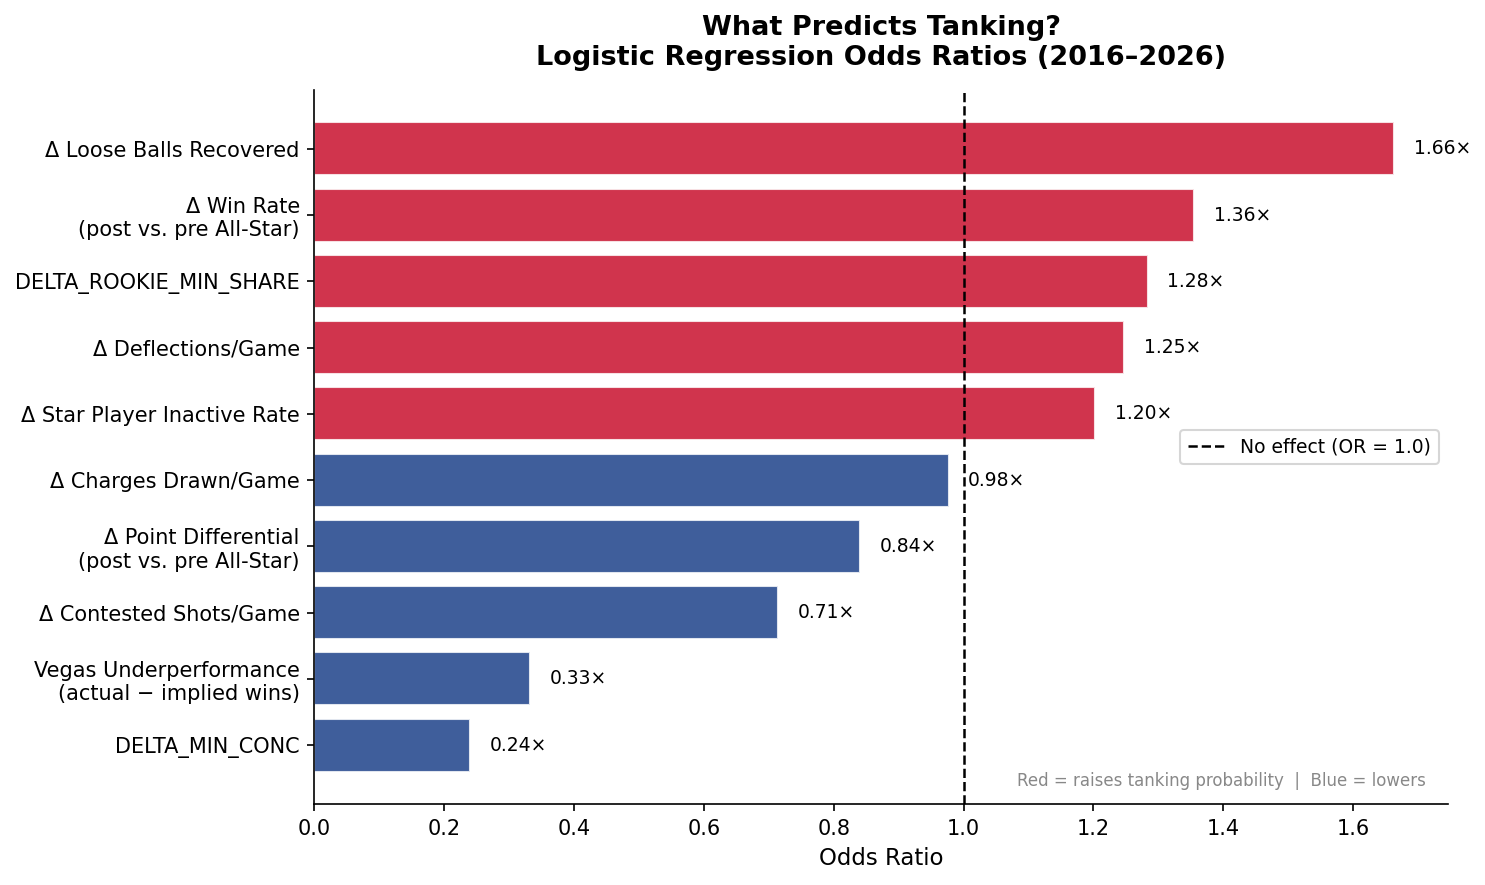

In [12]:
LABEL_MAP = {
    "DELTA_PM":                    "Δ Point Differential\n(post vs. pre All-Star)",
    "DELTA_WR":                    "Δ Win Rate\n(post vs. pre All-Star)",
    "DELTA_DEFLECTIONS":           "Δ Deflections/Game",
    "DELTA_CONTESTED_SHOTS":       "Δ Contested Shots/Game",
    "DELTA_LOOSE_BALLS_RECOVERED": "Δ Loose Balls Recovered",
    "DELTA_CHARGES_DRAWN":         "Δ Charges Drawn/Game",
    "DELTA_INACTIVE_RATE":         "Δ Star Player Inactive Rate",
    "ROSTER_AGE":                  "Average Roster Age",
    "UNDERPERFORMANCE":            "Vegas Underperformance\n(actual − implied wins)",
    "DELTA_TOP5_MIN_AVG":         "Δ Star Player Avg Mins"
}

coefs       = model.coef_[0]
odds_ratios = np.exp(coefs)
labels      = [LABEL_MAP.get(f, f) for f in FEATURE_COLS]

# Verify lengths match before plotting
assert len(labels) == len(odds_ratios), \
    f"Mismatch: {len(labels)} labels vs {len(odds_ratios)} odds ratios"

sorted_idx = np.argsort(odds_ratios)
sorted_or  = odds_ratios[sorted_idx]
sorted_lbl = [labels[i] for i in sorted_idx]
colors     = [LEAGUE_RED if o > 1 else LEAGUE_BLUE for o in sorted_or]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_lbl, sorted_or, color=colors, alpha=0.85, edgecolor="white")
ax.axvline(1.0, color="black", lw=1.2, ls="--", label="No effect (OR = 1.0)")

for bar, val in zip(bars, sorted_or):
    ax.text(val + 0.03, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}×", va="center", fontsize=9)

ax.set_xlabel("Odds Ratio", fontsize=11)
ax.set_title("What Predicts Tanking?\nLogistic Regression Odds Ratios (2016–2026)",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.text(0.98, 0.02,
        "Red = raises tanking probability  |  Blue = lowers",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig("outputs/fig_odds_ratios.png", bbox_inches="tight")
plt.show()

In [13]:
pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": model.coef_[0],
    "abs_coefficient": abs(model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

,feature,coefficient,abs_coefficient
8,DELTA_MIN_CONC,-1.425935,1.425935
7,UNDERPERFORMANCE,-1.100678,1.100678
4,DELTA_LOOSE_BALLS_RECOVERED,0.508696,0.508696
3,DELTA_CONTESTED_SHOTS,-0.337161,0.337161
1,DELTA_WR,0.303980,0.303980
9,DELTA_ROOKIE_MIN_SHARE,0.249763,0.249763
2,DELTA_DEFLECTIONS,0.221260,0.221260
6,DELTA_INACTIVE_RATE,0.184573,0.184573
0,DELTA_PM,-0.172968,0.172968
5,DELTA_CHARGES_DRAWN,-0.023518,0.023518


## Tanking Watch Index

In [20]:
from sklearn.preprocessing import RobustScaler

TWI_FEATURES = ["DELTA_PM", "DELTA_MIN_CONC", "DELTA_ROOKIE_MIN_SHARE", "DELTA_INACTIVE_RATE"]

twi_df = model_df[["TEAM_ID","TEAM_NAME","TEAM_ABB","SEASON",
                    "WINS","VEGAS_WINS","UNDERPERFORMANCE",
                    "GROUND_TRUTH","TANK_PROB"] + TWI_FEATURES].copy()

# Invert so higher = more tanking risk
# DELTA_PM: lower = worse performance = more tanking risk
# DELTA_MIN_CONC: lower = more diffuse minutes = more tanking risk
# DELTA_ROOKIE_MIN_SHARE: higher = more rookie mins = more tanking risk (no invert)
# ROSTER_AGE: lower = younger roster = more tanking risk
twi_df["TWI_PM"]          = -twi_df["DELTA_PM"]
twi_df["TWI_MIN_CONC"]    = -twi_df["DELTA_MIN_CONC"]
twi_df["TWI_ROOKIE"]      =  twi_df["DELTA_ROOKIE_MIN_SHARE"]
twi_df["TWI_INACTIVE"]      =  twi_df["DELTA_INACTIVE_RATE"]

# RobustScaler — resistant to outliers
scaler_twi = RobustScaler()
twi_components = ["TWI_PM", "TWI_MIN_CONC", "TWI_ROOKIE", "TWI_INACTIVE"]
twi_df[twi_components] = scaler_twi.fit_transform(twi_df[twi_components])

# Clip extreme values at 99th percentile before averaging
for col in twi_components:
    p99 = twi_df[col].quantile(0.99)
    twi_df[col] = twi_df[col].clip(upper=p99)

# Normalize to 0-100 after clipping
for col in twi_components:
    col_min = twi_df[col].min()
    col_max = twi_df[col].max()
    twi_df[col] = (twi_df[col] - col_min) / (col_max - col_min) * 100

# Equal weighted average
twi_df["TWI"] = twi_df[twi_components].mean(axis=1)

# ── Flagging ──────────────────────────────────────────────────────────────────
WINS_GATE  = 33
INV_THRESH = 60

def compute_flag(row):
    if row["WINS"] > WINS_GATE:
        return "Above Win Gate"
    if row["TWI"] >= INV_THRESH:
        return "Investigate"
    return "No Action"

twi_df["TWI_FLAG"] = twi_df.apply(compute_flag, axis=1)
model_df["TWI"]      = twi_df["TWI"]
model_df["TWI_FLAG"] = twi_df["TWI_FLAG"]

twi_df.to_csv("outputs/twi_scores.csv", index=False)

print(f"✓ TWI computed: {len(twi_df)} team-seasons")
print(f"\nGroup means validation:")
print(f"  Tanking teams — DELTA_PM: {model_df[model_df['TANKING']==1]['DELTA_PM'].mean():.3f} | DELTA_MIN_CONC: {model_df[model_df['TANKING']==1]['DELTA_MIN_CONC'].mean():.3f} | DELTA_ROOKIE_MIN_SHARE: {model_df[model_df['TANKING']==1]['DELTA_ROOKIE_MIN_SHARE'].mean():.3f} | DELTA_INACTIVE_RATE: {model_df[model_df['TANKING']==1]['DELTA_INACTIVE_RATE'].mean():.3f} ")
print(f"  Non-tanking   — DELTA_PM: {model_df[model_df['TANKING']==0]['DELTA_PM'].mean():.3f} | DELTA_MIN_CONC: {model_df[model_df['TANKING']==0]['DELTA_MIN_CONC'].mean():.3f} | DELTA_ROOKIE_MIN_SHARE: {model_df[model_df['TANKING']==0]['DELTA_ROOKIE_MIN_SHARE'].mean():.3f} | DELTA_INACTIVE_RATE: {model_df[model_df['TANKING']==0 ]['DELTA_INACTIVE_RATE'].mean():.3f}")

print(f"\nThreshold breakdown:")
print(twi_df["TWI_FLAG"].value_counts().to_string())

print(f"\nFlagged for investigation (TWI ≥ {INV_THRESH}, Wins ≤ {WINS_GATE}):")
print(twi_df[twi_df["TWI_FLAG"] == "Investigate"]
      [["TEAM_NAME","SEASON","WINS","UNDERPERFORMANCE","TWI","GROUND_TRUTH"]]
      .sort_values("TWI", ascending=False)
      .to_string(index=False))

flagged_gt = twi_df[
    (twi_df["TWI_FLAG"] == "Investigate") &
    (twi_df["GROUND_TRUTH"] == 1)
].shape[0]
total_gt = (twi_df["GROUND_TRUTH"] == 1).sum()
print(f"\nRecall: {flagged_gt}/{total_gt} known tankers flagged ({flagged_gt/total_gt:.1%})")

✓ TWI computed: 300 team-seasons

Group means validation:
  Tanking teams — DELTA_PM: -3.415 | DELTA_MIN_CONC: -0.199 | DELTA_ROOKIE_MIN_SHARE: 0.035 | DELTA_INACTIVE_RATE: 0.220 
  Non-tanking   — DELTA_PM: 0.306 | DELTA_MIN_CONC: -0.046 | DELTA_ROOKIE_MIN_SHARE: 0.007 | DELTA_INACTIVE_RATE: 0.016

Threshold breakdown:
TWI_FLAG
Above Win Gate    209
Investigate        51
No Action          40

Flagged for investigation (TWI ≥ 60, Wins ≤ 33):
             TEAM_NAME  SEASON  WINS  UNDERPERFORMANCE       TWI  GROUND_TRUTH
Portland Trail Blazers 2022-23    33              -6.5 92.867280             1
             Utah Jazz 2025-26    22               3.5 90.745675             1
Portland Trail Blazers 2021-22    27             -17.5 88.507483             1
 Oklahoma City Thunder 2021-22    24               0.5 87.936428             1
         Brooklyn Nets 2025-26    20               0.5 84.191221             1
     Memphis Grizzlies 2023-24    27             -18.5 84.113039             0


## Tanking Watch Index Sensitivity Analysis

In [32]:
# TWI Weight Sensitivity Analysis
print("\nTWI Weight Sensitivity Analysis")
print("="*60)
print("Testing alternative weighting schemes vs. equal weight baseline\n")

weight_schemes = {
    "Equal (baseline)":  {"TWI_PM": 0.25, "TWI_MIN_CONC": 0.25, "TWI_ROOKIE": 0.25, "TWI_INACTIVE": 0.25},
    "PM Heavy":          {"TWI_PM": 0.40, "TWI_MIN_CONC": 0.25, "TWI_ROOKIE": 0.15, "TWI_INACTIVE": 0.20},
    "Min Conc Heavy":    {"TWI_PM": 0.20, "TWI_MIN_CONC": 0.40, "TWI_ROOKIE": 0.20, "TWI_INACTIVE": 0.20},
    "Inactive Heavy":    {"TWI_PM": 0.20, "TWI_MIN_CONC": 0.25, "TWI_ROOKIE": 0.15, "TWI_INACTIVE": 0.40},
    "Behavioral Heavy":  {"TWI_PM": 0.15, "TWI_MIN_CONC": 0.30, "TWI_ROOKIE": 0.25, "TWI_INACTIVE": 0.30},
}

print(f"{'Scheme':<25} {'Recall':>8} {'Flagged':>9} {'Precision':>10} {'Avg TWI (tankers)':>18} {'Avg TWI (non)':>14}")
print("-"*85)

for name, weights in weight_schemes.items():
    twi_df["TWI_TEST"] = (
        twi_df["TWI_PM"]       * weights["TWI_PM"] +
        twi_df["TWI_MIN_CONC"] * weights["TWI_MIN_CONC"] +
        twi_df["TWI_ROOKIE"]   * weights["TWI_ROOKIE"] +
        twi_df["TWI_INACTIVE"] * weights["TWI_INACTIVE"]
    )

    flagged   = twi_df[(twi_df["TWI_TEST"] >= INV_THRESH) & (twi_df["WINS"] <= WINS_GATE)]
    n_tankers = (twi_df["GROUND_TRUTH"] == 1).sum()
    recall    = flagged["GROUND_TRUTH"].sum() / n_tankers if n_tankers > 0 else 0
    precision = flagged["GROUND_TRUTH"].mean() if len(flagged) > 0 else 0
    avg_tank  = twi_df[twi_df["GROUND_TRUTH"]==1]["TWI_TEST"].mean()
    avg_non   = twi_df[twi_df["GROUND_TRUTH"]==0]["TWI_TEST"].mean()

    print(f"{name:<25} {recall:>8.1%} {len(flagged):>9d} {precision:>10.1%} {avg_tank:>18.1f} {avg_non:>14.1f}")

# Clean up test column
twi_df.drop(columns=["TWI_TEST"], inplace=True)


TWI Weight Sensitivity Analysis
Testing alternative weighting schemes vs. equal weight baseline

Scheme                      Recall   Flagged  Precision  Avg TWI (tankers)  Avg TWI (non)
-------------------------------------------------------------------------------------
Equal (baseline)             82.8%        51      47.1%               70.7           51.1
PM Heavy                     79.3%        52      44.2%               70.3           50.4
Min Conc Heavy               86.2%        52      48.1%               71.6           49.5
Inactive Heavy               82.8%        53      45.3%               72.5           51.2
Behavioral Heavy             82.8%        52      46.2%               71.7           50.9


## Reweighting the Tanking Watch Index

In [34]:
from sklearn.preprocessing import RobustScaler

TWI_FEATURES = ["DELTA_PM", "DELTA_MIN_CONC", "DELTA_ROOKIE_MIN_SHARE", "DELTA_INACTIVE_RATE"]

twi_df = model_df[["TEAM_ID","TEAM_NAME","TEAM_ABB","SEASON",
                    "WINS","VEGAS_WINS","UNDERPERFORMANCE",
                    "GROUND_TRUTH","TANK_PROB"] + TWI_FEATURES].copy()

# Invert so higher = more tanking risk
# DELTA_PM: lower = worse performance = more tanking risk
# DELTA_MIN_CONC: lower = more diffuse minutes = more tanking risk
# DELTA_ROOKIE_MIN_SHARE: higher = more rookie mins = more tanking risk (no invert)
twi_df["TWI_PM"]       = -twi_df["DELTA_PM"]
twi_df["TWI_MIN_CONC"] = -twi_df["DELTA_MIN_CONC"]
twi_df["TWI_ROOKIE"]   =  twi_df["DELTA_ROOKIE_MIN_SHARE"]
twi_df["TWI_INACTIVE"]      =  twi_df["DELTA_INACTIVE_RATE"]

# RobustScaler — resistant to outliers
scaler_twi = RobustScaler()
twi_components = ["TWI_PM", "TWI_MIN_CONC", "TWI_ROOKIE", "TWI_INACTIVE"]
twi_df[twi_components] = scaler_twi.fit_transform(twi_df[twi_components])

# Clip extreme values at 99th percentile before averaging
for col in twi_components:
    p99 = twi_df[col].quantile(0.99)
    twi_df[col] = twi_df[col].clip(upper=p99)

# Normalize to 0-100 after clipping
for col in twi_components:
    col_min = twi_df[col].min()
    col_max = twi_df[col].max()
    twi_df[col] = (twi_df[col] - col_min) / (col_max - col_min) * 100

# Min Conc Heavy weighting — upweights intentional deployment signal
# Justified: minutes concentration reflects deliberate roster decisions,
# harder to attribute to injury or randomness than PM or rookie share alone
TWI_WEIGHTS = {"TWI_PM": 0.20, "TWI_MIN_CONC": 0.40, "TWI_ROOKIE": 0.20, "TWI_INACTIVE": 0.20}
twi_df["TWI"] = (
    twi_df["TWI_PM"]       * TWI_WEIGHTS["TWI_PM"] +
    twi_df["TWI_MIN_CONC"] * TWI_WEIGHTS["TWI_MIN_CONC"] +
    twi_df["TWI_ROOKIE"]   * TWI_WEIGHTS["TWI_ROOKIE"] +
    twi_df["TWI_INACTIVE"] * TWI_WEIGHTS["TWI_INACTIVE"]
)
# ── Flagging ──────────────────────────────────────────────────────────────────
WINS_GATE  = 33
INV_THRESH = 60

def compute_flag(row):
    if row["WINS"] > WINS_GATE:
        return "Above Win Gate"
    if row["TWI"] >= INV_THRESH:
        return "Investigate"
    return "No Action"

twi_df["TWI_FLAG"] = twi_df.apply(compute_flag, axis=1)
model_df["TWI"]      = twi_df["TWI"]
model_df["TWI_FLAG"] = twi_df["TWI_FLAG"]

twi_df.to_csv("outputs/twi_scores.csv", index=False)

print(f"✓ TWI computed: {len(twi_df)} team-seasons")
print(f"  Weights — PM: {TWI_WEIGHTS['TWI_PM']:.0%} | Min Conc: {TWI_WEIGHTS['TWI_MIN_CONC']:.0%} | Rookie: {TWI_WEIGHTS['TWI_ROOKIE']:.0%} | Inactive: {TWI_WEIGHTS['TWI_INACTIVE']:.0%}")
print(f"\nGroup means validation:")
print(f"  Tanking teams — DELTA_PM: {model_df[model_df['TANKING']==1]['DELTA_PM'].mean():.3f} | DELTA_MIN_CONC: {model_df[model_df['TANKING']==1]['DELTA_MIN_CONC'].mean():.3f} | DELTA_ROOKIE_MIN_SHARE: {model_df[model_df['TANKING']==1]['DELTA_ROOKIE_MIN_SHARE'].mean():.3f} | DELTA_INACTIVE_RATE: {model_df[model_df['TANKING']==1]['DELTA_INACTIVE_RATE'].mean():.3f}")
print(f"  Non-tanking   — DELTA_PM: {model_df[model_df['TANKING']==0]['DELTA_PM'].mean():.3f} | DELTA_MIN_CONC: {model_df[model_df['TANKING']==0]['DELTA_MIN_CONC'].mean():.3f} | DELTA_ROOKIE_MIN_SHARE: {model_df[model_df['TANKING']==0]['DELTA_ROOKIE_MIN_SHARE'].mean():.3f} | DELTA_INACTIVE_RATE: {model_df[model_df['TANKING']==0]['DELTA_INACTIVE_RATE'].mean():.3f}")
print(f"\nThreshold breakdown:")
print(twi_df["TWI_FLAG"].value_counts().to_string())
print(f"\nFlagged for investigation (TWI ≥ {INV_THRESH}, Wins ≤ {WINS_GATE}):")
print(twi_df[twi_df["TWI_FLAG"] == "Investigate"]
      [["TEAM_NAME","SEASON","WINS","UNDERPERFORMANCE","TWI","GROUND_TRUTH"]]
      .sort_values("TWI", ascending=False)
      .to_string(index=False))

flagged_gt = twi_df[
    (twi_df["TWI_FLAG"] == "Investigate") &
    (twi_df["GROUND_TRUTH"] == 1)
].shape[0]
total_gt = (twi_df["GROUND_TRUTH"] == 1).sum()
print(f"\nRecall: {flagged_gt}/{total_gt} known tankers flagged ({flagged_gt/total_gt:.1%})")

✓ TWI computed: 300 team-seasons
  Weights — PM: 20% | Min Conc: 40% | Rookie: 20% | Inactive: 20%

Group means validation:
  Tanking teams — DELTA_PM: -3.415 | DELTA_MIN_CONC: -0.199 | DELTA_ROOKIE_MIN_SHARE: 0.035 | DELTA_INACTIVE_RATE: 0.220
  Non-tanking   — DELTA_PM: 0.306 | DELTA_MIN_CONC: -0.046 | DELTA_ROOKIE_MIN_SHARE: 0.007 | DELTA_INACTIVE_RATE: 0.016

Threshold breakdown:
TWI_FLAG
Above Win Gate    209
Investigate        52
No Action          39

Flagged for investigation (TWI ≥ 60, Wins ≤ 33):
             TEAM_NAME  SEASON  WINS  UNDERPERFORMANCE       TWI  GROUND_TRUTH
Portland Trail Blazers 2022-23    33              -6.5 94.293824             1
             Utah Jazz 2025-26    22               3.5 92.596540             1
Portland Trail Blazers 2021-22    27             -17.5 87.096707             1
 Oklahoma City Thunder 2021-22    24               0.5 86.702624             1
     Memphis Grizzlies 2023-24    27             -18.5 85.209216             0
         Brook

## EDA Boxplots

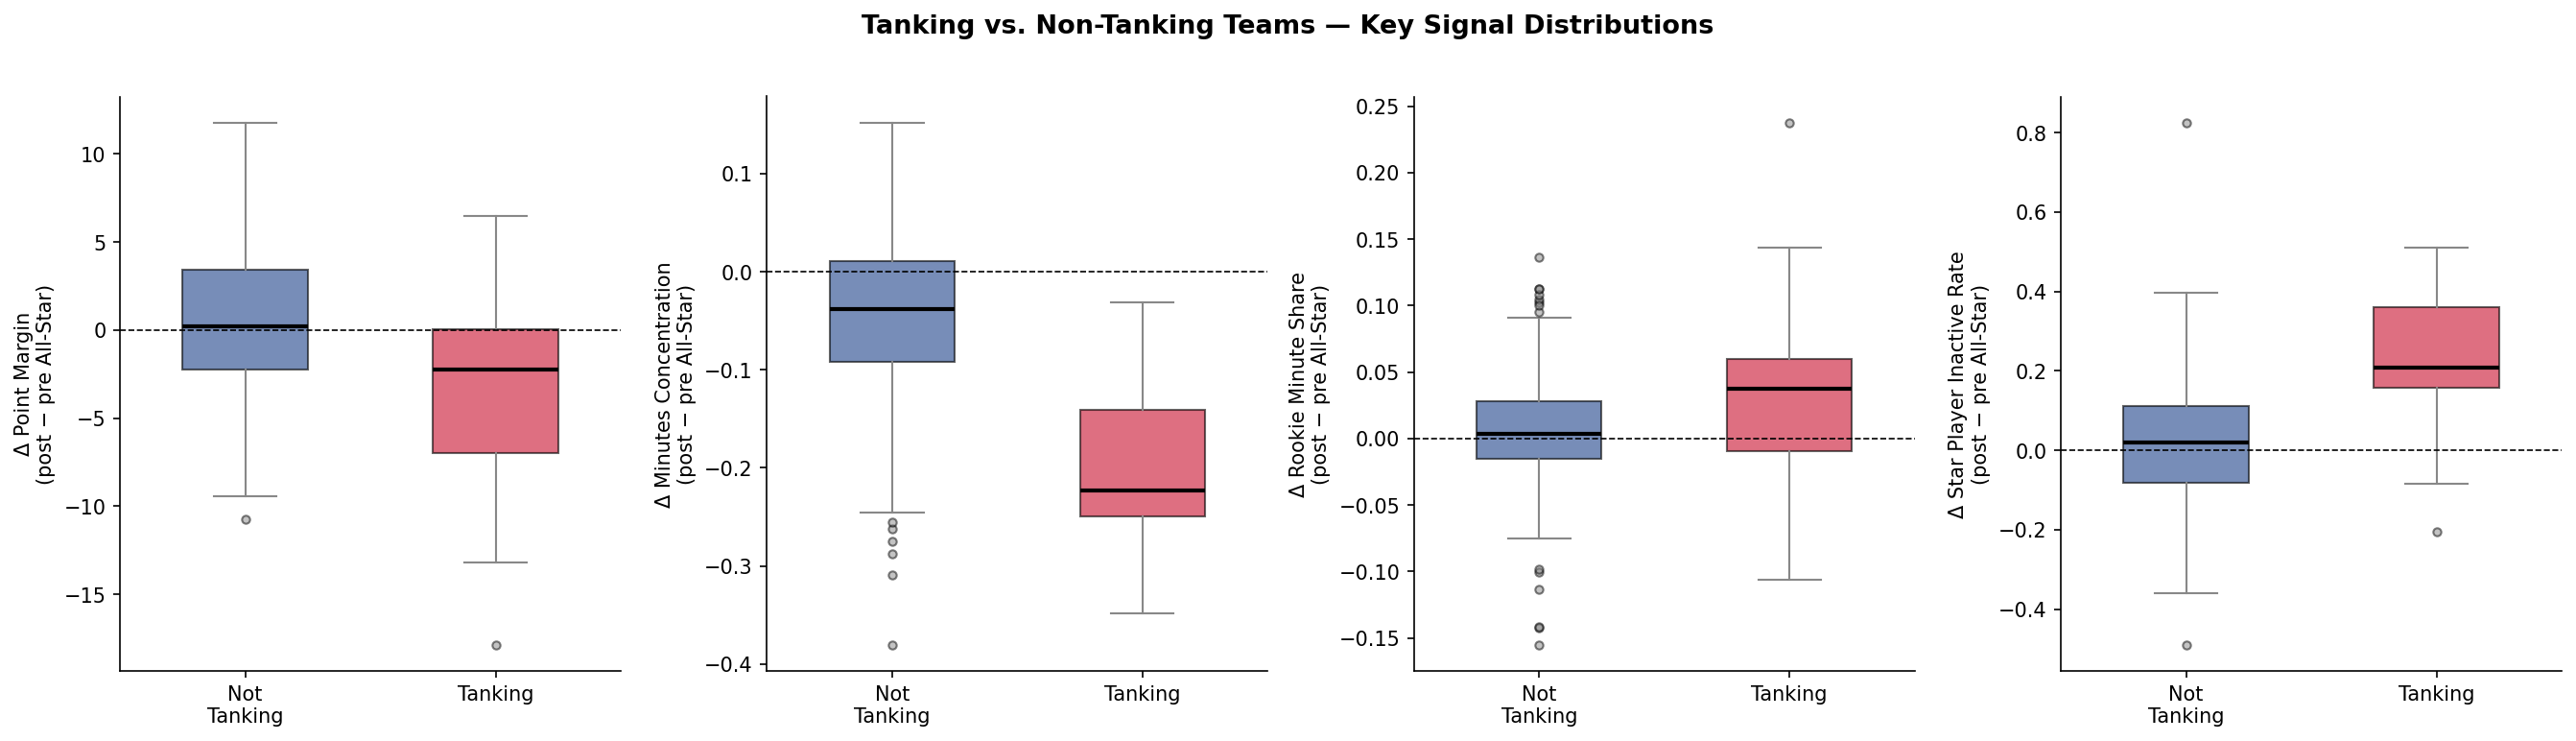

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = [
    ("DELTA_PM",               "Δ Point Margin\n(post − pre All-Star)"),
    ("DELTA_MIN_CONC",         "Δ Minutes Concentration\n(post − pre All-Star)"),
    ("DELTA_ROOKIE_MIN_SHARE", "Δ Rookie Minute Share\n(post − pre All-Star)"),
    ("DELTA_INACTIVE_RATE",    "Δ Star Player Inactive Rate\n(post − pre All-Star)"),
]
for ax, (col, ylabel) in zip(axes, metrics):
    if col not in model_df.columns:
        ax.set_title(f"{col}\nnot available")
        continue
    data = [model_df[model_df["TANKING"]==0][col].dropna(),
            model_df[model_df["TANKING"]==1][col].dropna()]
    bp = ax.boxplot(data, labels=["Not\nTanking","Tanking"],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(color=GRAY),
                    capprops=dict(color=GRAY),
                    flierprops=dict(marker="o", markerfacecolor=GRAY,
                                   markersize=4, alpha=0.5))
    for patch, color in zip(bp["boxes"], [LEAGUE_BLUE, LEAGUE_RED]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color="black", lw=0.8, ls="--")
plt.suptitle("Tanking vs. Non-Tanking Teams — Key Signal Distributions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/fig_eda_boxplots.png", bbox_inches="tight")
plt.show()

## Heatmaps

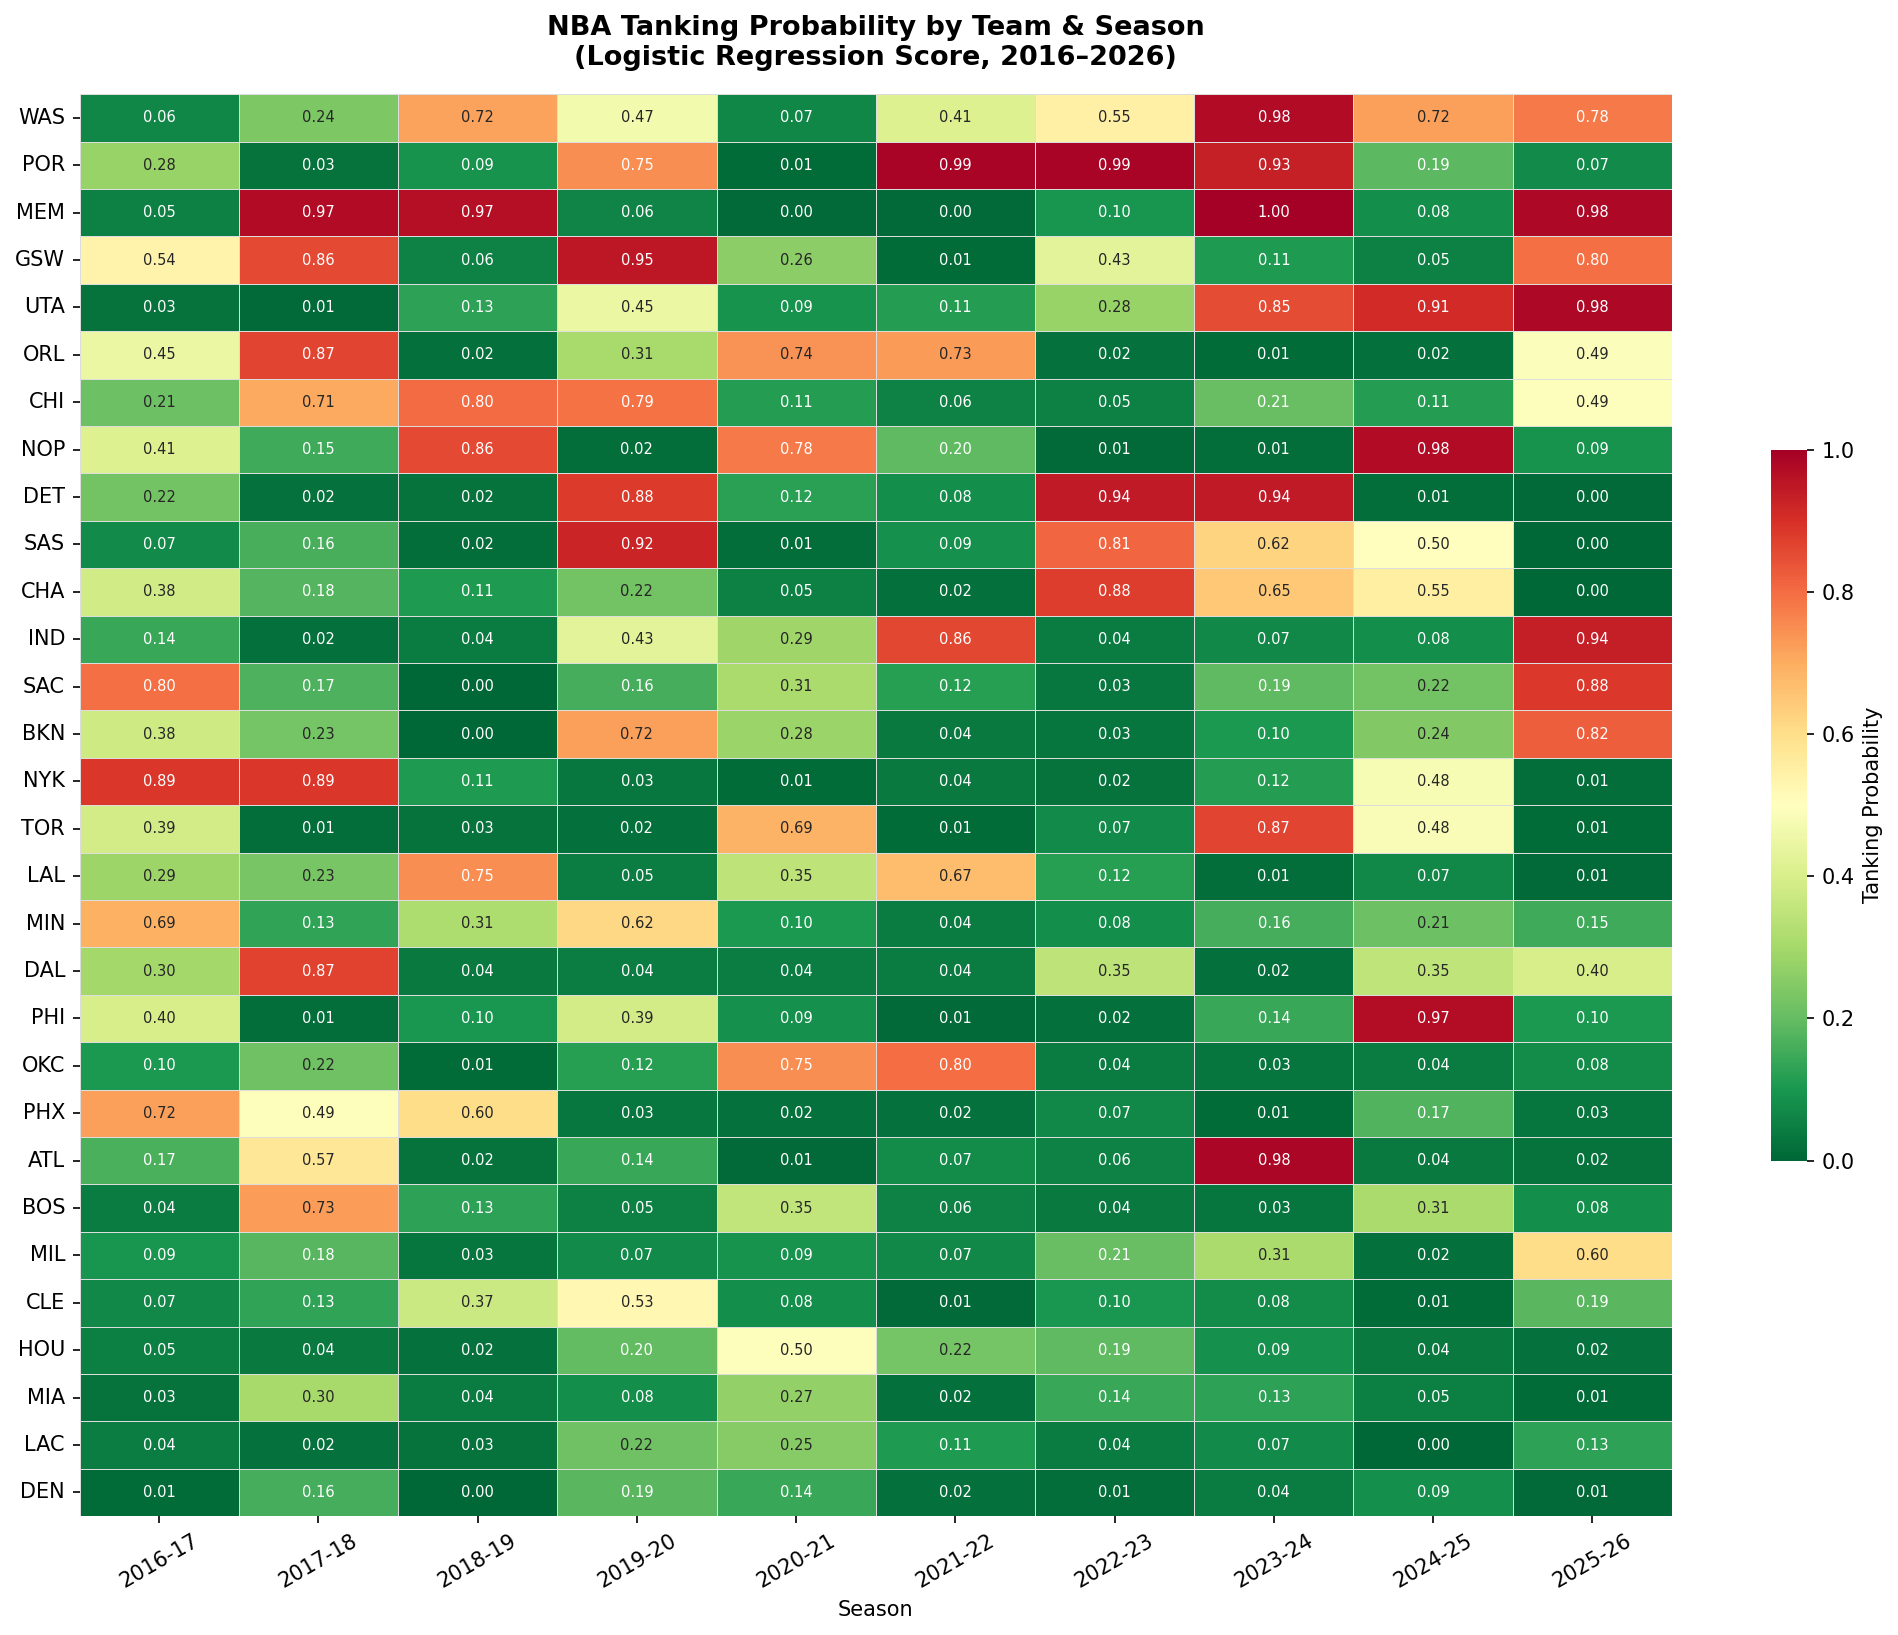

Saved: outputs/fig_tanking_heatmap.png


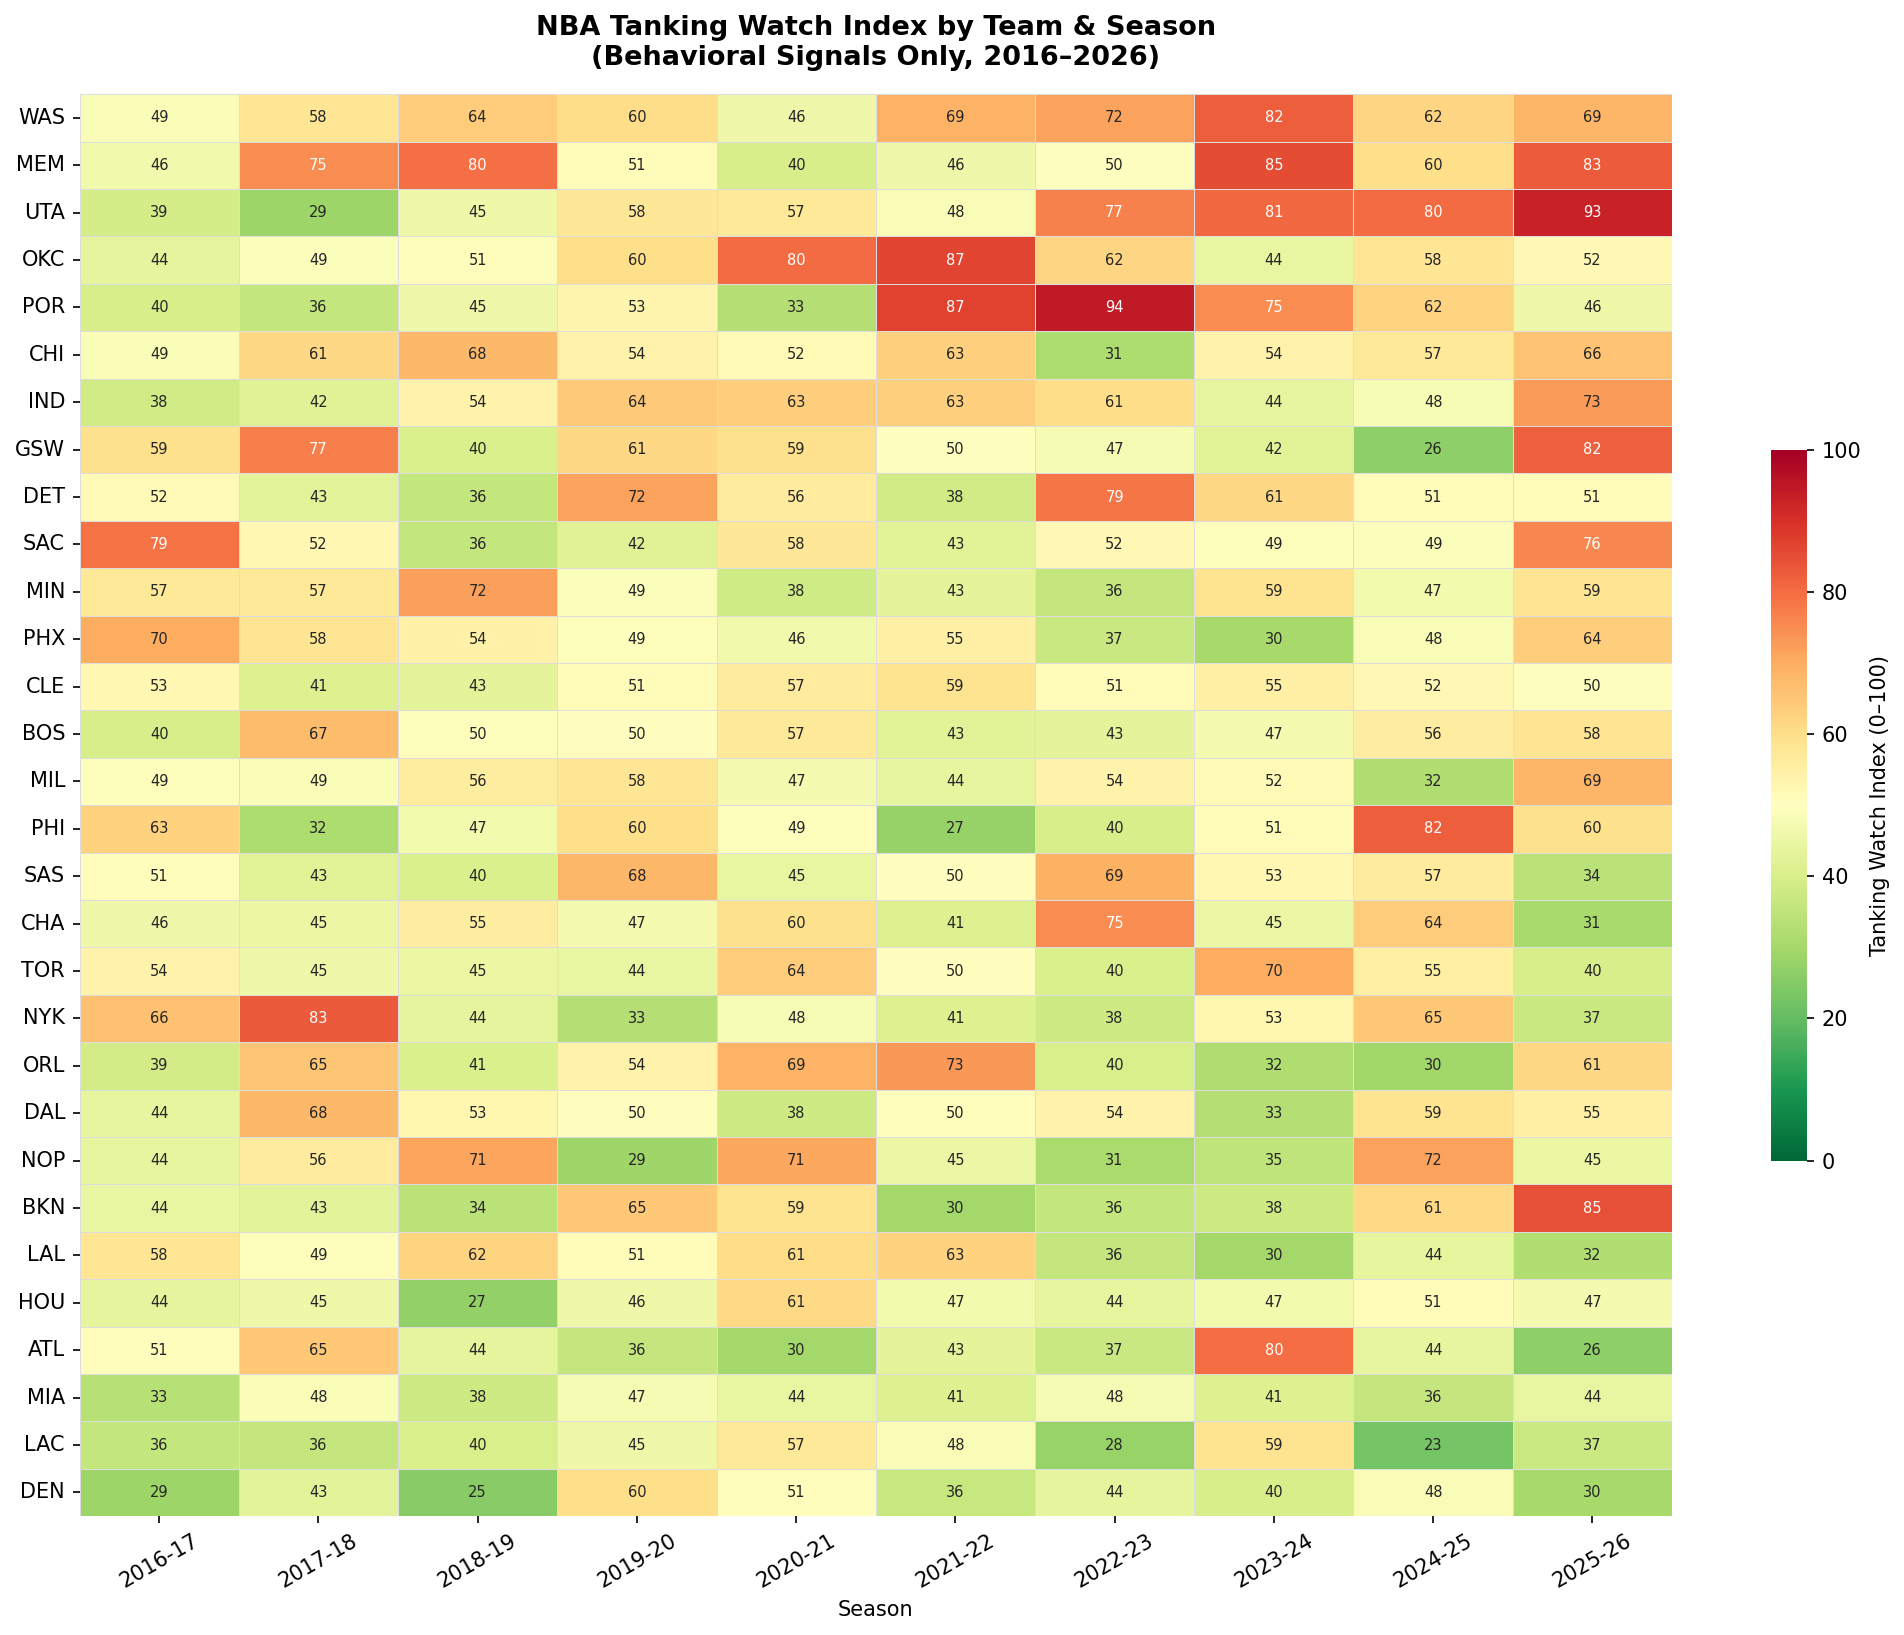

Saved: outputs/fig_twi_heatmap.png


In [36]:
# Heatmap 1 — Logistic Regression Tanking Probability
pivot_prob = model_df.pivot_table(
    index="TEAM_ABB", columns="SEASON", values="TANK_PROB", aggfunc="mean"
)
pivot_prob["AVG"] = pivot_prob.mean(axis=1)
pivot_prob = pivot_prob.sort_values("AVG", ascending=False).drop(columns="AVG")

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    pivot_prob, cmap="RdYlGn_r", vmin=0, vmax=1,
    annot=True, fmt=".2f", linewidths=0.4, linecolor="#dddddd",
    ax=ax,
    cbar_kws={"label": "Tanking Probability", "shrink": 0.5},
    annot_kws={"size": 7},
)
ax.set_title("NBA Tanking Probability by Team & Season\n(Logistic Regression Score, 2016–2026)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Season")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("outputs/fig_tanking_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/fig_tanking_heatmap.png")

# Heatmap 2 — Tanking Watch Index (TWI)
pivot_twi = model_df.pivot_table(
    index="TEAM_ABB", columns="SEASON", values="TWI", aggfunc="mean"
)
pivot_twi["AVG"] = pivot_twi.mean(axis=1)
pivot_twi = pivot_twi.sort_values("AVG", ascending=False).drop(columns="AVG")

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    pivot_twi, cmap="RdYlGn_r", vmin=0, vmax=100,
    annot=True, fmt=".0f", linewidths=0.4, linecolor="#dddddd",
    ax=ax,
    cbar_kws={"label": "Tanking Watch Index (0–100)", "shrink": 0.5},
    annot_kws={"size": 7},
)
ax.set_title("NBA Tanking Watch Index by Team & Season\n(Behavioral Signals Only, 2016–2026)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Season")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("outputs/fig_twi_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/fig_twi_heatmap.png")

## ROC Curve & Confusion Matrix

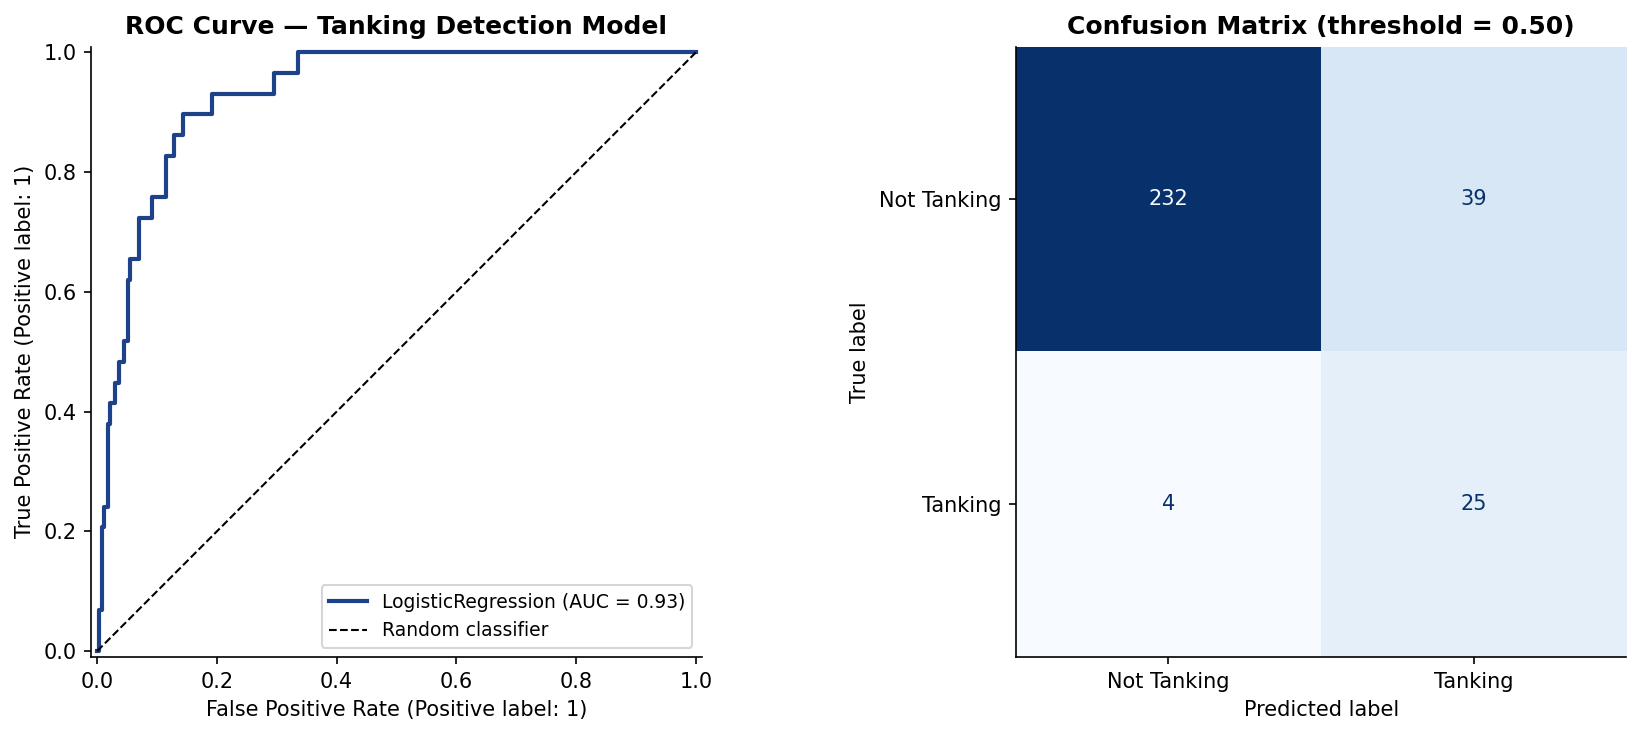

Saved: outputs/fig_model_performance.png


In [37]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(model, X_scaled, y, ax=axes[0],
                                color=LEAGUE_BLUE, lw=2)
axes[0].plot([0,1],[0,1],"k--",lw=1,label="Random classifier")
axes[0].set_title("ROC Curve — Tanking Detection Model",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

ConfusionMatrixDisplay.from_estimator(
    model, X_scaled, y, ax=axes[1],
    cmap="Blues", colorbar=False,
    display_labels=["Not Tanking","Tanking"],
)
axes[1].set_title("Confusion Matrix (threshold = 0.50)",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/fig_model_performance.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/fig_model_performance.png")

## Case Studies

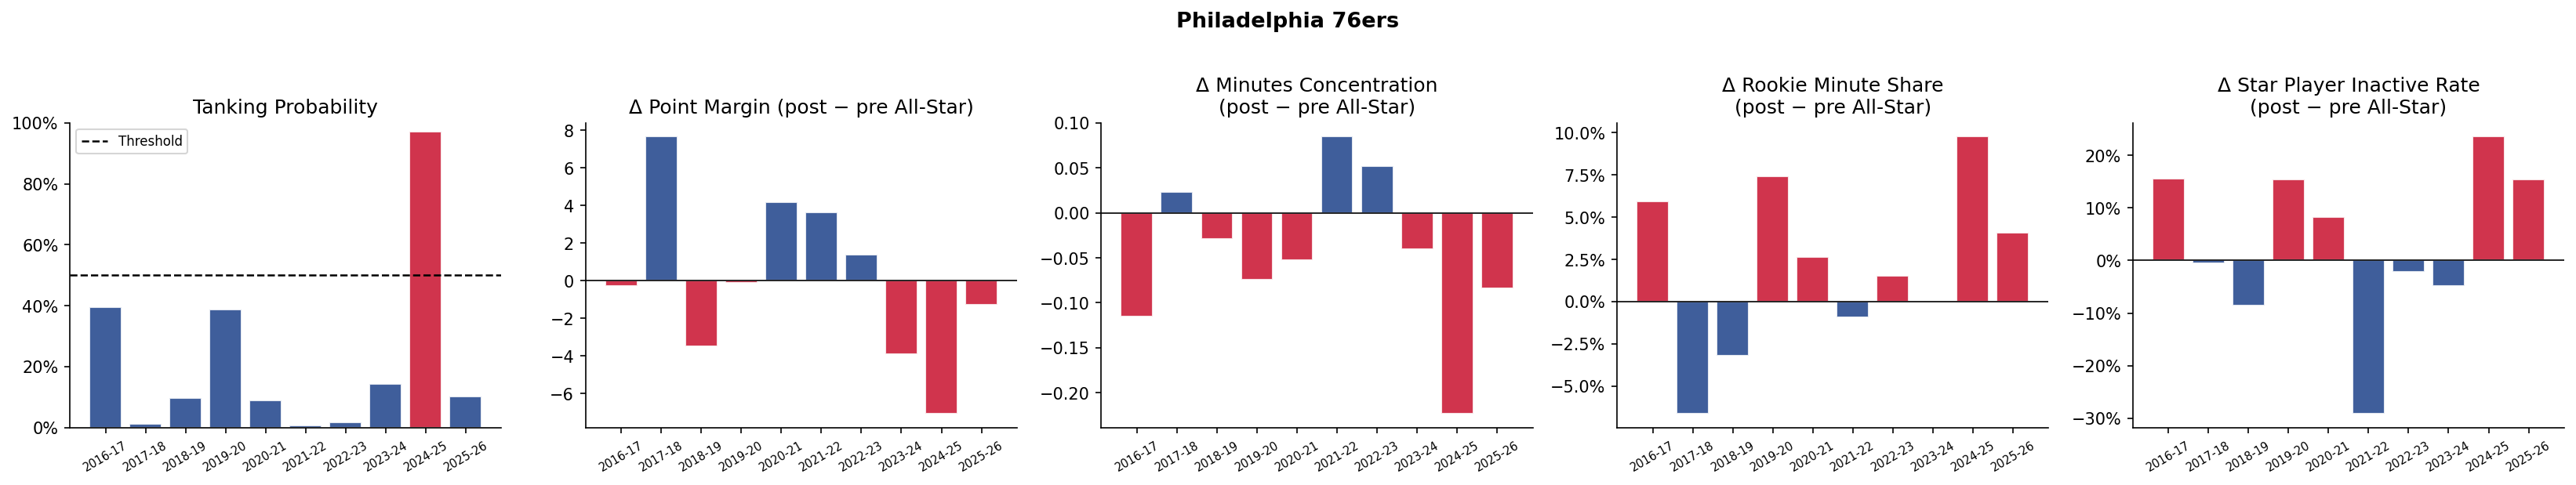

Saved: outputs/fig_case_PHI.png


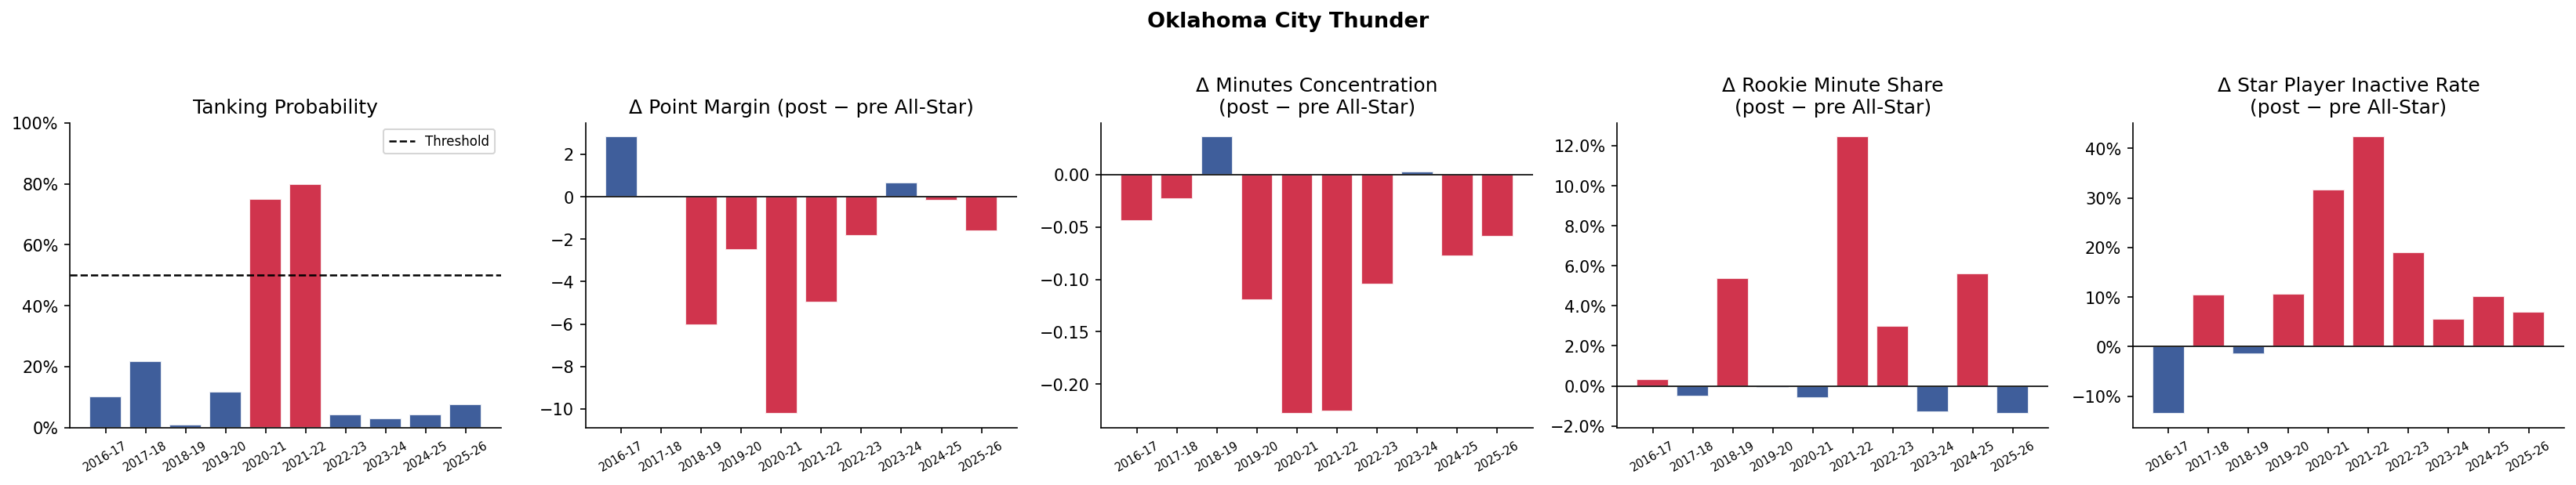

Saved: outputs/fig_case_OKC.png


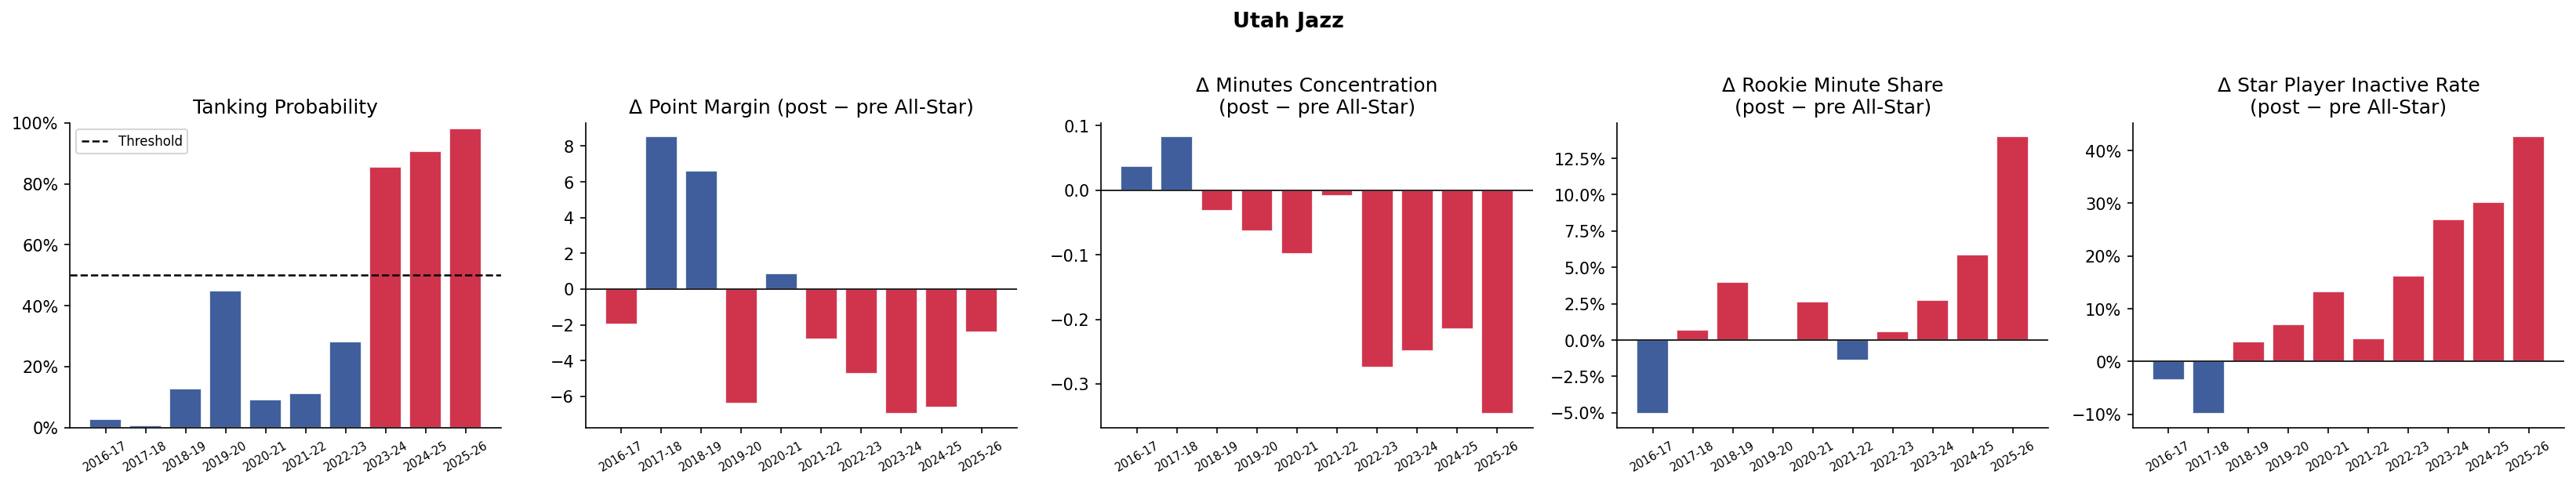

Saved: outputs/fig_case_UTA.png


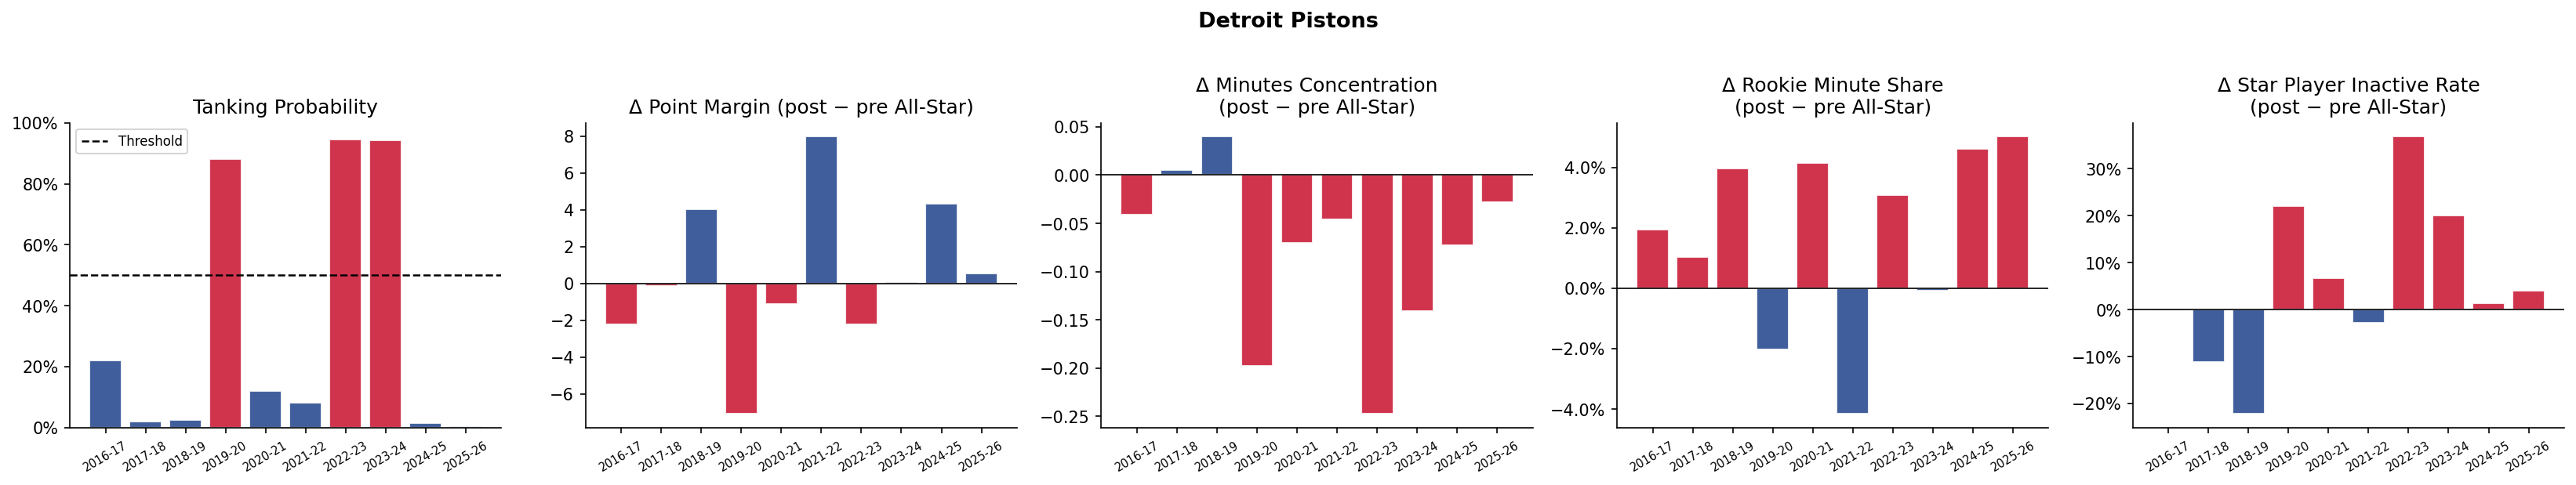

Saved: outputs/fig_case_DET.png


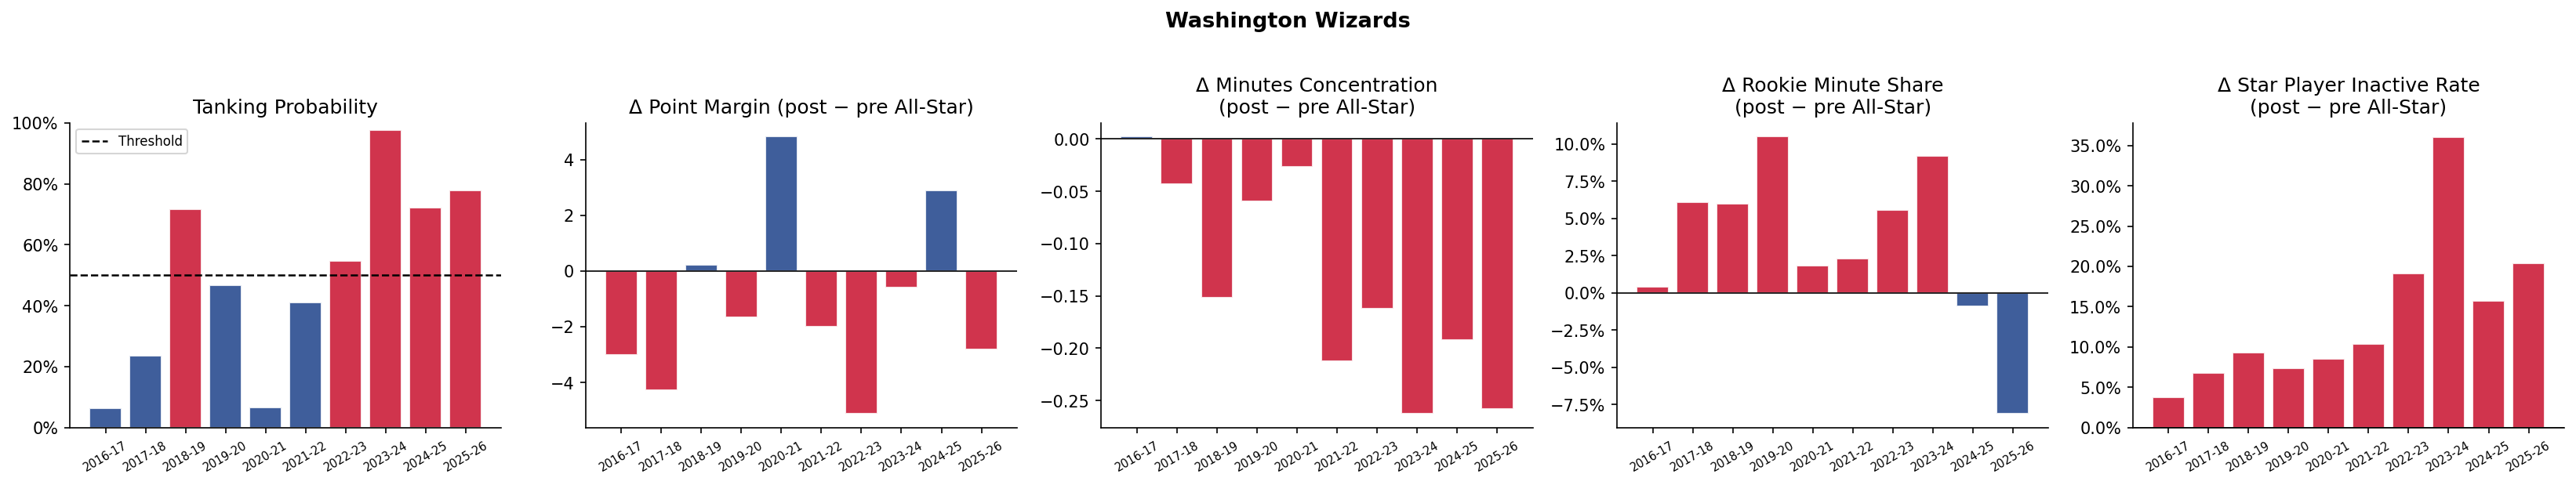

Saved: outputs/fig_case_WAS.png


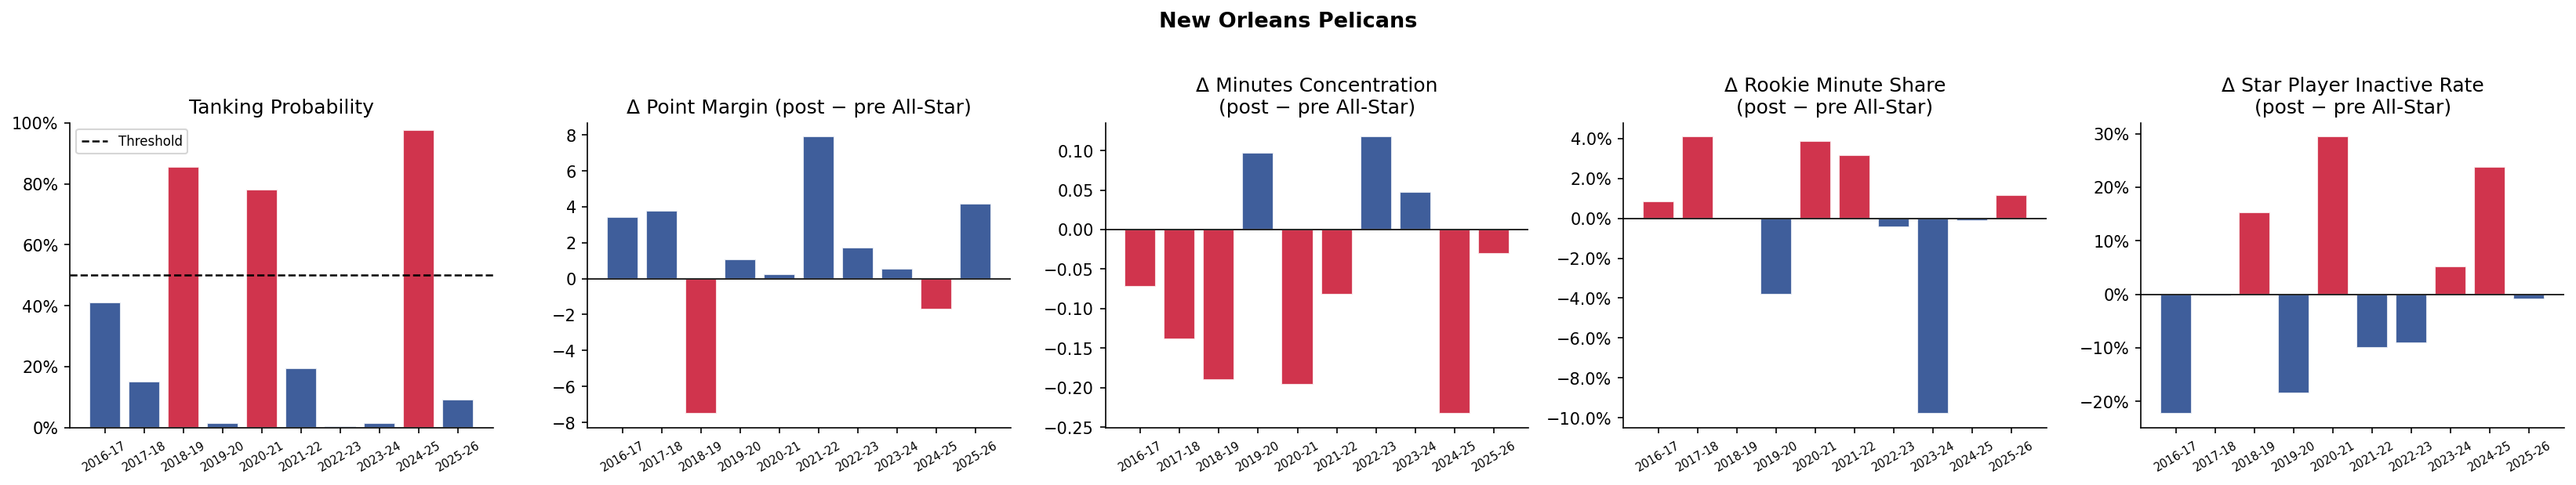

Saved: outputs/fig_case_NOP.png


In [38]:
def plot_case_study(df, team_abb):
    td = df[df["TEAM_ABB"] == team_abb].sort_values("SEASON")
    if td.empty:
        print(f"No data for {team_abb}")
        return
    team_name = td["TEAM_NAME"].iloc[0]
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    seasons   = list(range(len(td)))

    # Panel 1: Tanking probability
    axes[0].bar(seasons, td["TANK_PROB"],
                color=[LEAGUE_RED if p > 0.5 else LEAGUE_BLUE
                       for p in td["TANK_PROB"]],
                alpha=0.85, edgecolor="white")
    axes[0].axhline(0.5, color="black", ls="--", lw=1.2, label="Threshold")
    axes[0].set_xticks(seasons)
    axes[0].set_xticklabels(td["SEASON"], rotation=30, fontsize=7)
    axes[0].set_title("Tanking Probability")
    axes[0].set_ylim(0, 1)
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[0].legend(fontsize=8)

    # Panel 2: Δ Point Margin
    axes[1].bar(seasons, td["DELTA_PM"],
                color=[LEAGUE_RED if d < 0 else LEAGUE_BLUE
                       for d in td["DELTA_PM"]],
                alpha=0.85, edgecolor="white")
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_xticks(seasons)
    axes[1].set_xticklabels(td["SEASON"], rotation=30, fontsize=7)
    axes[1].set_title("Δ Point Margin (post − pre All-Star)")

    # Panel 3: Δ Minutes Concentration
    axes[2].bar(seasons, td["DELTA_MIN_CONC"],
                color=[LEAGUE_RED if d < 0 else LEAGUE_BLUE
                       for d in td["DELTA_MIN_CONC"]],
                alpha=0.85, edgecolor="white")
    axes[2].axhline(0, color="black", lw=0.8)
    axes[2].set_xticks(seasons)
    axes[2].set_xticklabels(td["SEASON"], rotation=30, fontsize=7)
    axes[2].set_title("Δ Minutes Concentration\n(post − pre All-Star)")

    # Panel 4: Δ Rookie Minute Share
    axes[3].bar(seasons, td["DELTA_ROOKIE_MIN_SHARE"],
                color=[LEAGUE_RED if d > 0 else LEAGUE_BLUE
                       for d in td["DELTA_ROOKIE_MIN_SHARE"]],
                alpha=0.85, edgecolor="white")
    axes[3].axhline(0, color="black", lw=0.8)
    axes[3].set_xticks(seasons)
    axes[3].set_xticklabels(td["SEASON"], rotation=30, fontsize=7)
    axes[3].set_title("Δ Rookie Minute Share\n(post − pre All-Star)")
    axes[3].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

    # Panel 5: Δ Star Player Inactive Rate
    axes[4].bar(seasons, td["DELTA_INACTIVE_RATE"],
                color=[LEAGUE_RED if d > 0 else LEAGUE_BLUE
                       for d in td["DELTA_INACTIVE_RATE"]],
                alpha=0.85, edgecolor="white")
    axes[4].axhline(0, color="black", lw=0.8)
    axes[4].set_xticks(seasons)
    axes[4].set_xticklabels(td["SEASON"], rotation=30, fontsize=7)
    axes[4].set_title("Δ Star Player Inactive Rate\n(post − pre All-Star)")
    axes[4].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

    fig.suptitle(team_name, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"outputs/fig_case_{team_abb}.png", bbox_inches="tight")
    plt.show()
    print(f"Saved: outputs/fig_case_{team_abb}.png")

for team in ["PHI", "OKC", "UTA", "DET", "WAS", "NOP"]:
    plot_case_study(model_df, team)

## Logistic Regression Sensitivity Analysis

In [39]:
print("Teams flagged at each threshold:\n")
print(f"{'Threshold':>10} {'Flagged':>8} {'% of Obs':>10} {'Avg/Season':>12}")
print("-" * 44)
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    n = (model_df["TANK_PROB"] >= t).sum()
    print(f"{t:>10.0%} {n:>8d} {n/len(model_df):>10.1%} {n/len(SEASONS):>12.1f}")

print("\nFlagged teams per season (threshold = 0.50):")
print(model_df.groupby("SEASON")
      .apply(lambda g: (g["TANK_PROB"] >= 0.5).sum())
      .reset_index(name="FLAGGED")
      .to_string(index=False))

Teams flagged at each threshold:

 Threshold  Flagged   % of Obs   Avg/Season
--------------------------------------------
       30%       94      31.3%          9.4
       40%       77      25.7%          7.7
       50%       64      21.3%          6.4
       60%       58      19.3%          5.8
       70%       50      16.7%          5.0

Flagged teams per season (threshold = 0.50):
 SEASON  FLAGGED
2016-17        5
2017-18        8
2018-19        6
2019-20        8
2020-21        4
2021-22        5
2022-23        5
2023-24        9
2024-25        6
2025-26        8


# Clustering

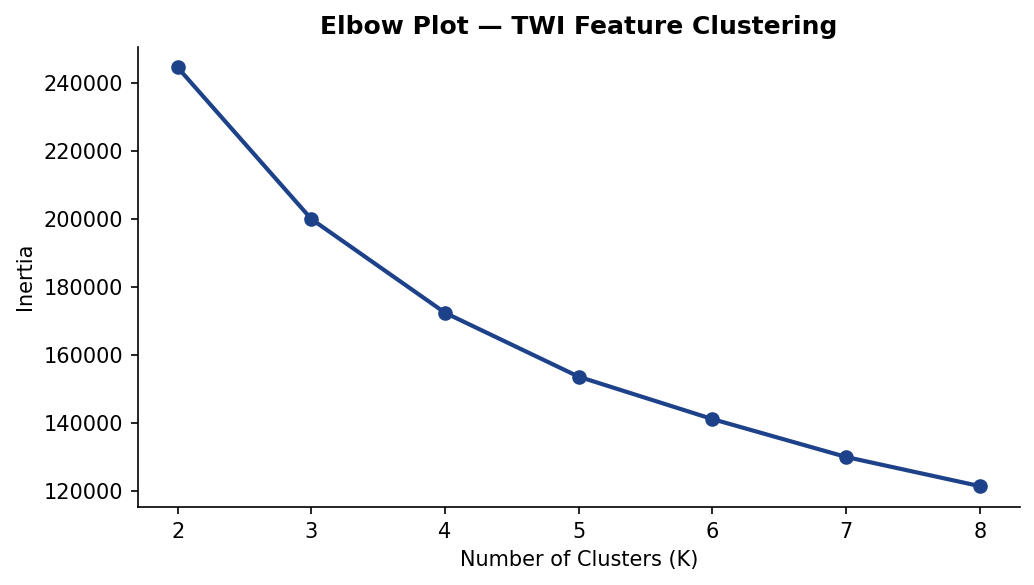

Cluster Summary:
 CLUSTER   n  tanking_rate   avg_twi  avg_wins
       1  57      0.368421 73.145696 28.719298
       0 115      0.034783 54.290074 42.930435
       2 128      0.031250 39.584858 42.226562

Tanking cluster (Cluster 1) overlap with KNOWN_TANKERS:
  Teams in cluster:      57
  Known tankers caught:  21/29 (72.4% recall)
  Precision:             36.8%

Adjusted Rand Index (clustering vs ground truth): 0.088
  (0 = random, 1 = perfect alignment)

Teams in tanking cluster sorted by TWI:
TEAM_ABB  SEASON  WINS       TWI  GROUND_TRUTH
     POR 2022-23    33 94.293824             1
     UTA 2025-26    22 92.596540             1
     POR 2021-22    27 87.096707             1
     OKC 2021-22    24 86.702624             1
     MEM 2023-24    27 85.209216             0
     BKN 2025-26    20 84.640331             1
     NYK 2017-18    29 82.869401             0
     MEM 2025-26    25 82.665476             1
     PHI 2024-25    24 82.415570             1
     WAS 2023-24    15 82.3

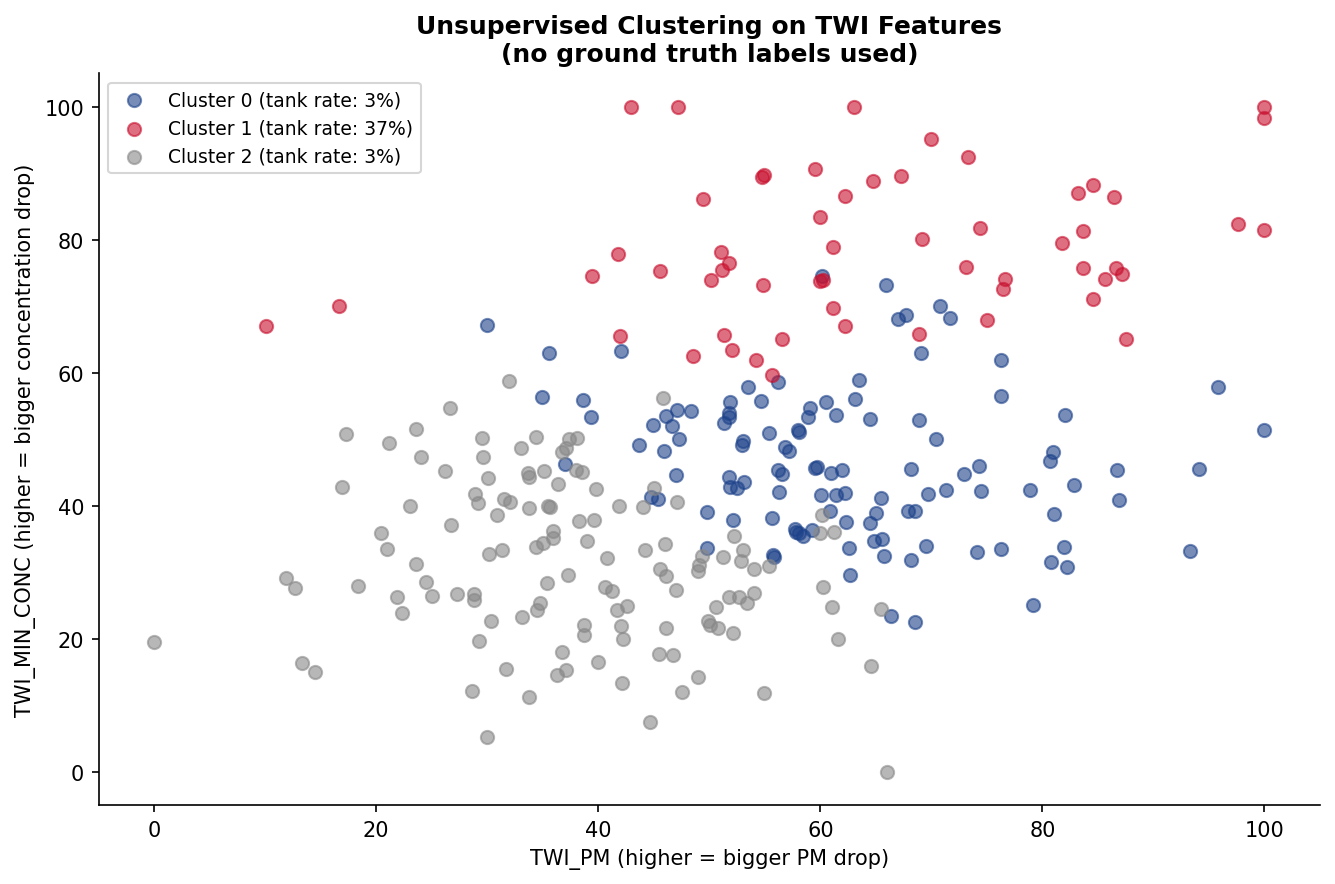

Saved: outputs/fig_cluster_elbow.png, fig_cluster_scatter.png


In [40]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

CLUSTER_FEATURES = ["TWI_PM", "TWI_MIN_CONC", "TWI_ROOKIE", "TWI_INACTIVE"]

# Use the already-scaled 0-100 components from twi_df
cluster_df = twi_df[["TEAM_ID","TEAM_NAME","TEAM_ABB","SEASON",
                       "WINS","GROUND_TRUTH","TWI"] + CLUSTER_FEATURES].copy().dropna()

X_clust = cluster_df[CLUSTER_FEATURES].values

# Elbow plot to choose K 
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, marker="o", color=LEAGUE_BLUE, lw=2)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Plot — TWI Feature Clustering", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig_cluster_elbow.png", bbox_inches="tight")
plt.show()

# Fit K=3 
# Three clusters makes intuitive sense: tanking, rebuilding-but-not-tanking, competing
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df["CLUSTER"] = km.fit_predict(X_clust)

#  Label clusters by tanking rate 
cluster_summary = (cluster_df.groupby("CLUSTER")
                   .agg(
                       n=("CLUSTER","count"),
                       tanking_rate=("GROUND_TRUTH","mean"),
                       avg_twi=("TWI","mean"),
                       avg_wins=("WINS","mean"),
                   )
                   .sort_values("tanking_rate", ascending=False)
                   .reset_index())

print("Cluster Summary:")
print(cluster_summary.to_string(index=False))

# Identify the tanking cluster — highest tanking rate
tank_cluster = cluster_summary.iloc[0]["CLUSTER"]
cluster_df["TANK_CLUSTER"] = (cluster_df["CLUSTER"] == tank_cluster).astype(int)

# ── Overlap with ground truth ─────────────────────────────────────────────────
in_tank_cluster   = cluster_df[cluster_df["TANK_CLUSTER"] == 1]
overlap           = in_tank_cluster["GROUND_TRUTH"].sum()
total_gt          = cluster_df["GROUND_TRUTH"].sum()
cluster_precision = overlap / len(in_tank_cluster)
cluster_recall    = overlap / total_gt

print(f"\nTanking cluster (Cluster {int(tank_cluster)}) overlap with KNOWN_TANKERS:")
print(f"  Teams in cluster:      {len(in_tank_cluster)}")
print(f"  Known tankers caught:  {int(overlap)}/{int(total_gt)} ({cluster_recall:.1%} recall)")
print(f"  Precision:             {cluster_precision:.1%}")

# ── ARI — how well does clustering align with ground truth labels ─────────────
ari = adjusted_rand_score(cluster_df["GROUND_TRUTH"], cluster_df["CLUSTER"])
print(f"\nAdjusted Rand Index (clustering vs ground truth): {ari:.3f}")
print("  (0 = random, 1 = perfect alignment)")

# ── Who's in the tanking cluster ─────────────────────────────────────────────
print(f"\nTeams in tanking cluster sorted by TWI:")
print(in_tank_cluster[["TEAM_ABB","SEASON","WINS","TWI","GROUND_TRUTH"]]
      .sort_values("TWI", ascending=False)
      .to_string(index=False))

# ── Scatter: TWI_PM vs TWI_MIN_CONC colored by cluster ───────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
colors = {int(tank_cluster): LEAGUE_RED}
palette = {c: (LEAGUE_RED if c == int(tank_cluster) else LEAGUE_BLUE if c == cluster_summary.iloc[1]["CLUSTER"] else GRAY)
           for c in cluster_df["CLUSTER"].unique()}

for cl, grp in cluster_df.groupby("CLUSTER"):
    ax.scatter(grp["TWI_PM"], grp["TWI_MIN_CONC"],
               color=palette[cl], alpha=0.6, s=40,
               label=f"Cluster {cl} (tank rate: {cluster_summary[cluster_summary['CLUSTER']==cl]['tanking_rate'].values[0]:.0%})")

ax.set_xlabel("TWI_PM (higher = bigger PM drop)")
ax.set_ylabel("TWI_MIN_CONC (higher = bigger concentration drop)")
ax.set_title("Unsupervised Clustering on TWI Features\n(no ground truth labels used)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig_cluster_scatter.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/fig_cluster_elbow.png, fig_cluster_scatter.png")

## Blowout Rate Chart

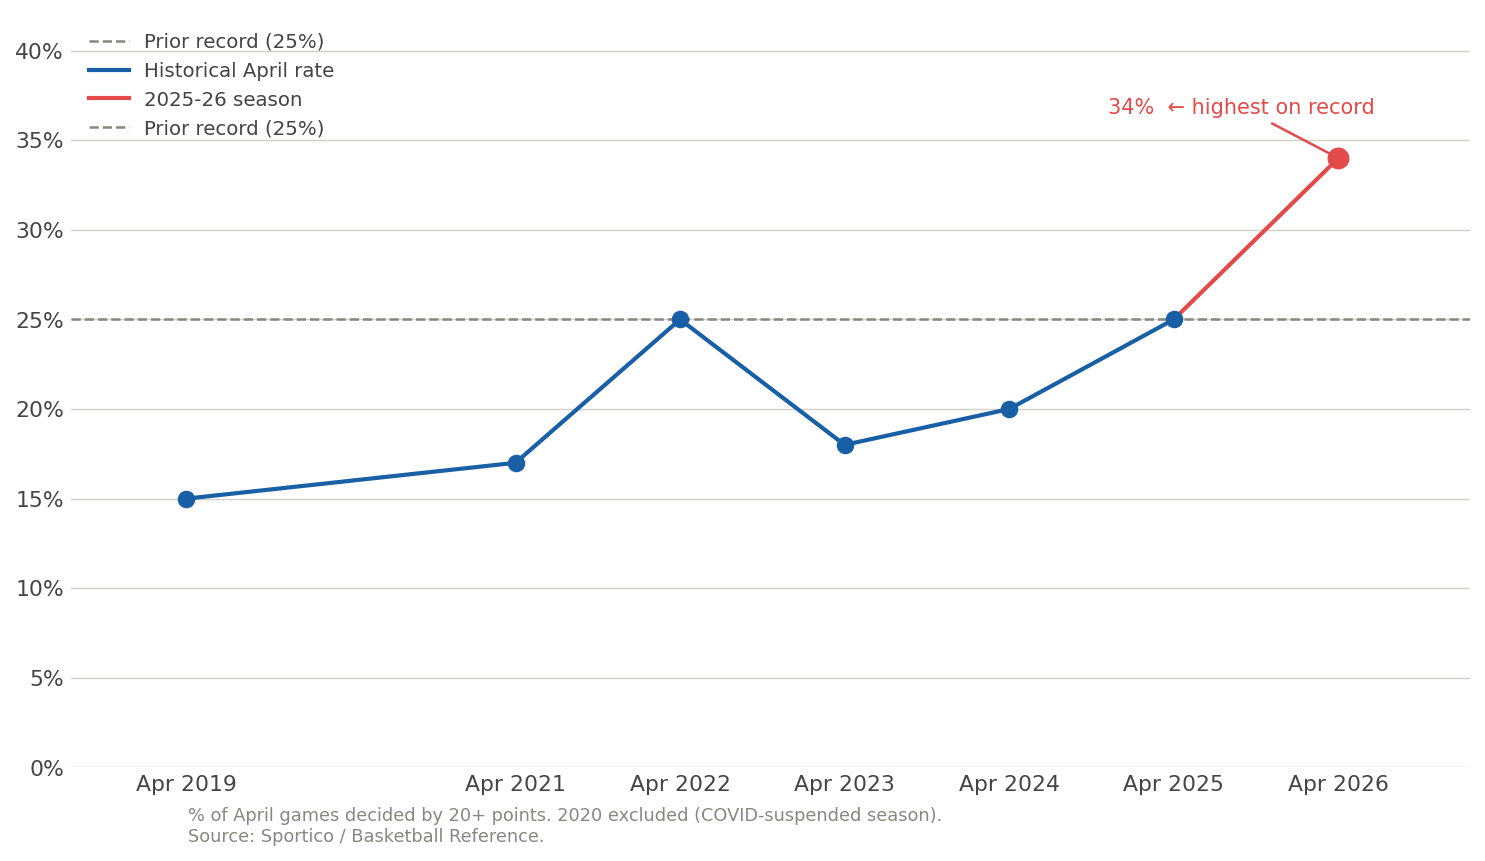

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

years = [2019, 2021, 2022, 2023, 2024, 2025, 2026]
rates = [15, 17, 25, 18, 20, 25, 34]
labels = [f"Apr {y}" for y in years]

BLUE = "#185FA5"
RED = "#E24B4A"
GRAY = "#888780"
LIGHT_GRAY = "#D3D1C7"

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Draw line segments — red for the last segment, blue for the rest
for i in range(len(years) - 1):
    color = RED if i == len(years) - 2 else BLUE
    ax.plot(
        [years[i], years[i + 1]],
        [rates[i], rates[i + 1]],
        color=color,
        linewidth=2,
        solid_capstyle="round",
        zorder=2,
    )

# Draw dots
for i, (x, y) in enumerate(zip(years, rates)):
    is_last = i == len(years) - 1
    color = RED if is_last else BLUE
    size = 90 if is_last else 55
    ax.scatter(x, y, color=color, s=size, zorder=3)

# Annotate the 2026 point
ax.annotate(
    "34%  ← highest on record",
    xy=(2026, 34),
    xytext=(2024.6, 36.5),
    fontsize=10,
    color=RED,
    fontweight="medium",
    arrowprops=dict(arrowstyle="-", color=RED, lw=1.2),
)

# Prior record dashed line
ax.axhline(25, color=GRAY, linewidth=1.2, linestyle="--", zorder=1, label="Prior record (25%)")

# Axes formatting
ax.set_xticks(years)
ax.set_xticklabels(labels, fontsize=10.5, color="#444441")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, 42)
ax.set_xlim(2018.3, 2026.8)
ax.tick_params(axis="y", labelsize=10.5, colors="#444441")
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# Legend
ax.plot([], [], color=BLUE, linewidth=2, label="Historical April rate")
ax.plot([], [], color=RED, linewidth=2, label="2025-26 season")
ax.plot([], [], color=GRAY, linewidth=1.2, linestyle="--", label="Prior record (25%)")
ax.legend(
    fontsize=9.5,
    frameon=False,
    loc="upper left",
    labelcolor="#444441",
)

# Caption
fig.text(
    0.13, -0.03,
    "% of April games decided by 20+ points. 2020 excluded (COVID-suspended season).\nSource: Sportico / Basketball Reference.",
    fontsize=8.5,
    color=GRAY,
    ha="left",
)

plt.tight_layout()